# 06 — Unified Model Evaluation
## Source of truth for the thesis: *is the model actually good?*

This notebook is the **read-only evaluator**. It ingests prediction CSVs produced
by training notebooks, constructs two analytical baselines internally, and computes
a unified metric table for the thesis write-up. No model training here.

**Validation window:** Oct 2025 – Mar 2026 (6 months held out from training)  
**Ground truth:** 3-class territorial control label — `gov` / `opo` / `uncertain`  
**N evaluated:** up to 894 labelled cell-months (cells in both target and feature matrix)


In [1]:
# ── CELL 0: Imports and Configuration ───────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
)

PROJECT_ROOT = Path('..').resolve()
DATA_PROC    = PROJECT_ROOT / 'data' / 'processed'
REPORTS      = PROJECT_ROOT / 'reports' / 'figures'
DOCS         = PROJECT_ROOT / 'docs'
DOCS.mkdir(parents=True, exist_ok=True)

# ── Split configuration — must match the training notebook ────────────────────
TRAIN_CUTOFF = '2025-01'   # val = months > this date (Oct 2025 – Mar 2026)

CLASS_NAMES  = ['gov', 'opo', 'uncertain']
LABEL_MAP    = {'gov': 0, 'opo': 1, 'uncertain': 2}
INV_LABEL    = {v: k for k, v in LABEL_MAP.items()}

# ── Prediction file registry ──────────────────────────────────────────────────
# Each entry: (model_label, path_to_prediction_csv)
# Format expected: priogrid_gid, year_month, pred_class_int  (+ optionally prob_* columns)
MODELS_DIR = PROJECT_ROOT / 'models'

PREDICTION_FILES = {
    'U-Net baseline'   : DATA_PROC / 'unet_predictions_all_months.csv',
    'U-Net focal mask' : DATA_PROC / 'unet_focal_mask_predictions.csv',
    '05_a: Recovered cells'        : MODELS_DIR / '05_a_recovered_cells'        / 'predictions.csv',
    '05_b: Graded CE'              : MODELS_DIR / '05_b_graded_ce'              / 'predictions.csv',
    '05_c: Masked Dice'            : MODELS_DIR / '05_c_masked_dice'            / 'predictions.csv',
    '05_d: Recovered+Masked Dice'  : MODELS_DIR / '05_d_recovered_and_masked_dice' / 'predictions.csv',
    # ── v2 models (trained on target_v2: Wikipedia-first, ACLED-fill only) ───
    'U-Net baseline v2'            : MODELS_DIR / '03_v2' / 'predictions.csv',
    '05_a: Recovered cells v2'     : MODELS_DIR / '05_a_v2_recovered_cells' / 'predictions.csv',
}

# v2 ground truth path (for v2 model evaluation)
TARGET_V2_PATH = DATA_PROC / '10_v2_target_variable.parquet'
V2_MODELS = {'U-Net baseline v2', '05_a: Recovered cells v2'}
print(f'v2 target path: {TARGET_V2_PATH}')
print(f'v2 target exists: {TARGET_V2_PATH.exists()}')

print('Configuration loaded.')
print(f'Validation window: months > {TRAIN_CUTOFF}')
print(f'Prediction files registered: {list(PREDICTION_FILES.keys())}')


v2 target path: /Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/data/processed/10_v2_target_variable.parquet
v2 target exists: True
Configuration loaded.
Validation window: months > 2025-01
Prediction files registered: ['U-Net baseline', 'U-Net focal mask', '05_a: Recovered cells', '05_b: Graded CE', '05_c: Masked Dice', '05_d: Recovered+Masked Dice', 'U-Net baseline v2', '05_a: Recovered cells v2']


In [2]:
# ── CELL 1: Load Ground Truth and Build Analytical Baselines ─────────────────

# ── 1.1 Load full target panel (all 29 months) ────────────────────────────────
# We need the full panel for the persistence baseline's t-1 lookup.
target_full = pd.read_parquet(DATA_PROC / '10_target_variable.parquet')
target_full['year_month'] = target_full['year_month'].astype(str)
target_full['label_int']  = target_full['target'].map(LABEL_MAP)

# ── 1.2 Restrict ground truth to validation window ────────────────────────────
gt_val = target_full[target_full['year_month'] > TRAIN_CUTOFF].copy()
gt_val = gt_val.reset_index(drop=True)

# ── 1.3 Build fast label lookup for prev-month access ─────────────────────────
label_lookup = (
    target_full
    .set_index(['priogrid_gid', 'year_month'])['label_int']
    .to_dict()
)

def prev_ym(ym):
    y, m = int(ym[:4]), int(ym[5:7])
    m -= 1
    if m == 0: y -= 1; m = 12
    return f'{y:04d}-{m:02d}'

# ── 1.4 Add prev_label column to gt_val ──────────────────────────────────────
gt_val['prev_label'] = gt_val.apply(
    lambda r: label_lookup.get((r['priogrid_gid'], prev_ym(r['year_month']))),
    axis=1
)

n_no_prev = gt_val['prev_label'].isna().sum()
print(f'Validation rows total          : {len(gt_val):,}')
print(f'Rows with no prev month in panel: {n_no_prev}')
if n_no_prev > 0:
    print(f'  (These are dropped from change-detection metrics — no t-1 reference)')

# ── 1.5 Build persistence baseline predictions ────────────────────────────────
# Predict y_t = y_{t-1}. Rows without a t-1 are kept but flagged.
gt_val['pred_persistence'] = gt_val['prev_label'].astype('Int64')  # Int64 allows NA

# ── 1.6 Build majority-class baseline (always predict gov=0) ─────────────────
gt_val['pred_majority'] = 0  # 0 = gov

print(f'\nGround truth label distribution (val):')
print(gt_val['target'].value_counts().to_string())
print(f'\nPrev-month label available for {gt_val["prev_label"].notna().sum():,}'
      f' / {len(gt_val):,} rows')

# ── 1.7 PRIOGRID → raster coordinate lookup (for maps later) ─────────────────
# Used to place cells on the 2D Myanmar grid for visualisation.
all_gids = target_full['priogrid_gid'].unique()
gcoords  = pd.DataFrame({
    'priogrid_gid': all_gids,
    'global_row'  : (all_gids - 1) // 720,
    'global_col'  : (all_gids - 1) % 720,
})
min_row = gcoords['global_row'].min()
min_col = gcoords['global_col'].min()
gcoords['local_row'] = gcoords['global_row'] - min_row
gcoords['local_col'] = gcoords['global_col'] - min_col
RASTER_H = gcoords['local_row'].max() + 1
RASTER_W = gcoords['local_col'].max() + 1
gid_to_rc = gcoords.set_index('priogrid_gid')[['local_row','local_col']].to_dict('index')

print(f'\nRaster grid: {RASTER_H} rows × {RASTER_W} cols')


Validation rows total          : 2,590
Rows with no prev month in panel: 0

Ground truth label distribution (val):
target
gov          1660
opo           655
uncertain     275

Prev-month label available for 2,590 / 2,590 rows

Raster grid: 37 rows × 17 cols


In [3]:
# ── CELL 2: Load Model Prediction CSVs ───────────────────────────────────────
# Each CSV must contain: priogrid_gid, year_month, pred_class_int
# Probability columns (prob_gov, prob_opo, prob_uncertain) are optional.
# Missing files are skipped with a warning.

model_preds = {}   # model_label -> DataFrame with val rows
model_probs = {}   # model_label -> DataFrame with probability cols (if available)

for model_label, fpath in PREDICTION_FILES.items():
    if not fpath.exists():
        print(f'WARNING: prediction file not found — skipping {model_label}')
        print(f'         Expected path: {fpath}')
        continue

    df = pd.read_csv(fpath)
    df['year_month'] = df['year_month'].astype(str)

    # Filter to validation window only
    val_df = df[df['year_month'] > TRAIN_CUTOFF].copy()

    # Filter to labelled rows if has_label column exists
    if 'has_label' in val_df.columns:
        val_df = val_df[val_df['has_label']].copy()

    # Ensure pred_class_int exists (try pred_class string if not)
    if 'pred_class_int' not in val_df.columns:
        if 'pred_class' in val_df.columns:
            val_df['pred_class_int'] = val_df['pred_class'].map(LABEL_MAP)
        else:
            print(f'WARNING: {model_label} CSV has no pred_class_int or pred_class column — skipping')
            continue

    model_preds[model_label] = val_df[['priogrid_gid','year_month','pred_class_int']].copy()

    # Store probability columns if present
    prob_cols = [c for c in val_df.columns if c.startswith('prob_')]
    if prob_cols:
        model_probs[model_label] = val_df[['priogrid_gid','year_month'] + prob_cols].copy()

    print(f'Loaded {model_label}: {len(val_df):,} val rows'
          f'  |  prob cols: {prob_cols if prob_cols else "none"}')

# Register the two in-notebook baselines
# They work on the full gt_val (before the has_label / pred-CSV filtering)
# We'll handle the intersection inside the metrics function.
print(f'\nAnalytical baselines (computed in-notebook):')
print(f'  Persistence (y_t = y_{{t-1}})  : always available')
print(f'  Majority class (always gov)    : always available')
print(f'\nTotal models to evaluate: {2 + len(model_preds)}')


Loaded U-Net baseline: 2,086 val rows  |  prob cols: ['prob_gov', 'prob_opo', 'prob_uncertain']
Loaded U-Net focal mask: 894 val rows  |  prob cols: ['prob_gov', 'prob_opo', 'prob_uncertain']
Loaded 05_a: Recovered cells: 2,562 val rows  |  prob cols: ['prob_gov', 'prob_opo', 'prob_uncertain']
Loaded 05_b: Graded CE: 2,086 val rows  |  prob cols: ['prob_gov', 'prob_opo', 'prob_uncertain']
Loaded 05_c: Masked Dice: 2,086 val rows  |  prob cols: ['prob_gov', 'prob_opo', 'prob_uncertain']
Loaded 05_d: Recovered+Masked Dice: 2,562 val rows  |  prob cols: ['prob_gov', 'prob_opo', 'prob_uncertain']
Loaded U-Net baseline v2: 2,090 val rows  |  prob cols: ['prob_gov', 'prob_opo', 'prob_uncertain']
Loaded 05_a: Recovered cells v2: 2,568 val rows  |  prob cols: ['prob_gov', 'prob_opo', 'prob_uncertain']

Analytical baselines (computed in-notebook):
  Persistence (y_t = y_{t-1})  : always available
  Majority class (always gov)    : always available

Total models to evaluate: 10


In [4]:
# ── CELL 3: Metric Functions ─────────────────────────────────────────────────

def safe_div(num, den, empty_val=np.nan):
    """Division that returns empty_val when denominator is 0."""
    return num / den if den > 0 else empty_val


def compute_all_metrics(y_true, y_pred, y_prev):
    """
    Compute the full metric suite for one model.

    y_true, y_pred, y_prev: integer arrays (gov=0, opo=1, uncertain=2)
    y_prev may contain NaN (rows without a t-1 are excluded from change metrics).

    Returns a dict with all metrics.
    """
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    y_prev = np.array(y_prev, dtype=float)

    # ── A. Cross-sectional metrics (all rows) ─────────────────────────────────
    yt_int  = y_true.astype(int)
    yp_int  = y_pred.astype(int)

    macro_f1   = f1_score(yt_int, yp_int, average='macro',    zero_division=0)
    raw_acc    = (yt_int == yp_int).mean()

    per_class = {}
    for cls, name in enumerate(CLASS_NAMES):
        prec = precision_score(yt_int, yp_int, labels=[cls], average='macro', zero_division=np.nan)
        rec  = recall_score   (yt_int, yp_int, labels=[cls], average='macro', zero_division=np.nan)
        f1   = f1_score       (yt_int, yp_int, labels=[cls], average='macro', zero_division=np.nan)
        per_class[name] = {'precision': prec, 'recall': rec, 'f1': f1}

    # ── B. Change-detection metrics (rows with a t-1 only) ────────────────────
    has_prev  = ~np.isnan(y_prev)
    yt_cd  = y_true[has_prev].astype(int)
    yp_cd  = y_pred[has_prev].astype(int)
    ypr_cd = y_prev[has_prev].astype(int)

    # Stable: ground truth unchanged from t-1
    stable_mask = (yt_cd == ypr_cd)
    stable_acc  = safe_div((yp_cd[stable_mask] == yt_cd[stable_mask]).sum(),
                           stable_mask.sum())

    # Transition: ground truth changed from t-1
    trans_mask   = (yt_cd != ypr_cd)
    trans_recall = safe_div((yp_cd[trans_mask] == yt_cd[trans_mask]).sum(),
                            trans_mask.sum())

    # Transition precision: model predicted a change (pred != prev)
    # Among those, fraction that were genuine changes AND correct class
    model_changed = (yp_cd != ypr_cd)
    if model_changed.sum() == 0:
        trans_prec = np.nan   # model never predicted a change
    else:
        correct_change = model_changed & trans_mask & (yp_cd == yt_cd)
        trans_prec = safe_div(correct_change.sum(), model_changed.sum())

    # Change-detection F1: binary did_change task
    changed_true = trans_mask.astype(int)
    changed_pred = model_changed.astype(int)
    if changed_true.sum() == 0:
        cd_f1 = np.nan
    else:
        cd_f1 = f1_score(changed_true, changed_pred, zero_division=0)

    # Direction accuracy: of cells where BOTH truth and model agree a change occurred,
    # what fraction got the right new class?
    both_changed = model_changed & trans_mask
    direction_acc = safe_div((yp_cd[both_changed] == yt_cd[both_changed]).sum(),
                             both_changed.sum())

    return {
        'macro_f1'          : macro_f1,
        'raw_acc'           : raw_acc,
        'stable_acc'        : stable_acc,
        'transition_recall' : trans_recall,
        'transition_prec'   : trans_prec,
        'cd_f1'             : cd_f1,
        'direction_acc'     : direction_acc,
        'per_class'         : per_class,
        'n_total'           : len(y_true),
        'n_stable'          : int(stable_mask.sum()),
        'n_transitions'     : int(trans_mask.sum()),
        'n_model_changes'   : int(model_changed.sum()),
    }


def merge_preds(gt_df, pred_series):
    """
    Align predictions with ground truth.
    pred_series: dict or Series indexed by (priogrid_gid, year_month).
    Returns (y_true, y_pred, y_prev) aligned arrays.
    """
    merged = gt_df[['priogrid_gid','year_month','label_int','prev_label']].copy()
    if isinstance(pred_series, pd.DataFrame):
        merged = merged.merge(
            pred_series[['priogrid_gid','year_month','pred_class_int']],
            on=['priogrid_gid','year_month'], how='inner'
        )
        merged = merged.rename(columns={'pred_class_int': 'pred'})
    else:
        # pred_series is a column already on merged (persistence/majority)
        merged['pred'] = pred_series
        merged = merged.dropna(subset=['pred'])

    return (
        merged['label_int'].values,
        merged['pred'].values,
        merged['prev_label'].values,
    )


print('Metric functions defined.')
print(f'Metrics: macro_f1, raw_acc, stable_acc, transition_recall,'
      f' transition_prec, cd_f1, direction_acc')


Metric functions defined.
Metrics: macro_f1, raw_acc, stable_acc, transition_recall, transition_prec, cd_f1, direction_acc


In [5]:
# ── CELL 4: Main Evaluation Table ────────────────────────────────────────────

results = {}  # model_label -> metrics dict

# ── Persistence baseline ─────────────────────────────────────────────────────
# Use rows where prev_label is available (drop first-appearance rows)
pers_df = gt_val.dropna(subset=['prev_label']).copy()
pers_df['pred'] = pers_df['prev_label']
y_t, y_p, y_prev = pers_df['label_int'].values, pers_df['pred'].values, pers_df['prev_label'].values
results['Persistence'] = compute_all_metrics(y_t, y_p, y_prev)
print(f'Persistence  : N={len(y_t):,}  macro_f1={results["Persistence"]["macro_f1"]:.3f}'
      f'  transition_recall={results["Persistence"]["transition_recall"]}')

# ── Majority-class baseline ──────────────────────────────────────────────────
maj_df = gt_val.copy()
maj_df['pred'] = 0  # always gov
y_t, y_p, y_prev = maj_df['label_int'].values, maj_df['pred'].values, maj_df['prev_label'].values
results['Majority (gov)'] = compute_all_metrics(y_t, y_p, y_prev)
print(f'Majority     : N={len(y_t):,}  macro_f1={results["Majority (gov)"]["macro_f1"]:.3f}'
      f'  raw_acc={results["Majority (gov)"]["raw_acc"]:.3f}')

# ── Neural network models (from CSVs) ────────────────────────────────────────
for model_label, pred_df in model_preds.items():
    y_t, y_p, y_prev = merge_preds(gt_val, pred_df)
    results[model_label] = compute_all_metrics(y_t, y_p, y_prev)
    m = results[model_label]
    print(f'{model_label:<20}: N={m["n_total"]:,}  macro_f1={m["macro_f1"]:.3f}'
          f'  transition_recall={m["transition_recall"]}')

# ── Assemble summary DataFrame ────────────────────────────────────────────────
rows = []
for label, m in results.items():
    rows.append({
        'Model'               : label,
        'N'                   : m['n_total'],
        'Macro F1'            : m['macro_f1'],
        'Raw acc'             : m['raw_acc'],
        'Stable acc'          : m['stable_acc'],
        'Transition recall'   : m['transition_recall'],
        'Transition prec'     : m['transition_prec'],
        'Change-detect F1'    : m['cd_f1'],
        'Direction acc'       : m['direction_acc'],
        'N stable'            : m['n_stable'],
        'N transitions'       : m['n_transitions'],
    })

eval_df = pd.DataFrame(rows).set_index('Model')

# ── Display ───────────────────────────────────────────────────────────────────
float_cols = ['Macro F1','Raw acc','Stable acc','Transition recall',
              'Transition prec','Change-detect F1','Direction acc']

print('\n' + '='*90)
print('MAIN EVALUATION TABLE')
print('='*90)
with pd.option_context('display.float_format', '{:.3f}'.format, 'display.max_columns', 20):
    print(eval_df[['N','Macro F1','Raw acc','Stable acc',
                   'Transition recall','Transition prec','Change-detect F1','Direction acc']].to_string())

# ── Sanity checks ─────────────────────────────────────────────────────────────
print('\n── Sanity checks ──')
tr_pers = results['Persistence']['transition_recall']
if not (np.isnan(tr_pers) or tr_pers == 0.0):
    print(f'  BUG: Persistence transition_recall = {tr_pers:.4f} (should be 0.0 or NaN)')
else:
    print(f'  OK: Persistence transition_recall = {tr_pers} (expected 0.0)')

maj_acc = results['Majority (gov)']['raw_acc']
gov_share = (gt_val['target'] == 'gov').mean()
print(f'  Majority raw_acc = {maj_acc:.3f}, gov share in val = {gov_share:.3f}  '
      f'(should match)')

# ── Save to CSV ───────────────────────────────────────────────────────────────
csv_out = DOCS / 'eval_table.csv'
eval_df.reset_index().to_csv(csv_out, index=False, float_format='%.4f')
print(f'\nTable saved to: {csv_out}')


Persistence  : N=2,590  macro_f1=0.972  transition_recall=0.0
Majority     : N=2,590  macro_f1=0.260  raw_acc=0.641
U-Net baseline      : N=2,086  macro_f1=0.767  transition_recall=0.35
U-Net focal mask    : N=894  macro_f1=0.900  transition_recall=0.45161290322580644
05_a: Recovered cells: N=2,562  macro_f1=0.805  transition_recall=0.45
05_b: Graded CE     : N=2,086  macro_f1=0.768  transition_recall=0.36666666666666664
05_c: Masked Dice   : N=2,086  macro_f1=0.797  transition_recall=0.31666666666666665
05_d: Recovered+Masked Dice: N=2,562  macro_f1=0.796  transition_recall=0.36666666666666664
U-Net baseline v2   : N=2,086  macro_f1=0.946  transition_recall=0.5
05_a: Recovered cells v2: N=2,562  macro_f1=0.880  transition_recall=0.38333333333333336

MAIN EVALUATION TABLE
                                N  Macro F1  Raw acc  Stable acc  Transition recall  Transition prec  Change-detect F1  Direction acc
Model                                                                              

In [6]:
# ── CELL 5: Per-Class Report and Subset Analyses ─────────────────────────────

# ── 5.1 Per-class precision / recall / F1 per model ──────────────────────────
print('=' * 80)
print('PER-CLASS METRICS')
print('=' * 80)

for model_label, m in results.items():
    print(f'\n{model_label}')
    print(f'  {"Class":<12} {"Precision":>10} {"Recall":>10} {"F1":>10}')
    print(f'  {"-"*45}')
    for cls in CLASS_NAMES:
        pc = m['per_class'][cls]
        p  = f"{pc["precision"]:.3f}" if not np.isnan(pc['precision']) else 'NaN'
        r  = f"{pc["recall"]:.3f}"    if not np.isnan(pc['recall'])    else 'NaN'
        f1 = f"{pc["f1"]:.3f}"        if not np.isnan(pc['f1'])        else 'NaN'
        print(f'  {cls:<12} {p:>10} {r:>10} {f1:>10}')


# ── 5.2 Helper: run full metrics on a subset of gt_val ────────────────────────
def eval_on_subset(subset_gt, subset_label):
    """
    Re-run all models on a filtered subset of gt_val.
    Returns a summary DataFrame.
    """
    sub_results = {}

    # Persistence
    sub = subset_gt.dropna(subset=['prev_label']).copy()
    sub['pred'] = sub['prev_label']
    if len(sub) > 0:
        sub_results['Persistence'] = compute_all_metrics(
            sub['label_int'].values, sub['pred'].values, sub['prev_label'].values)

    # Majority
    sub2 = subset_gt.copy(); sub2['pred'] = 0
    if len(sub2) > 0:
        sub_results['Majority (gov)'] = compute_all_metrics(
            sub2['label_int'].values, sub2['pred'].values, sub2['prev_label'].values)

    # Neural models
    for ml, pred_df in model_preds.items():
        y_t2, y_p2, y_pv2 = merge_preds(subset_gt, pred_df)
        if len(y_t2) > 0:
            sub_results[ml] = compute_all_metrics(y_t2, y_p2, y_pv2)

    rows2 = []
    for lbl, m in sub_results.items():
        rows2.append({'Model': lbl, 'N': m['n_total'],
                      'Macro F1': m['macro_f1'], 'Raw acc': m['raw_acc'],
                      'Stable acc': m['stable_acc'],
                      'Transition recall': m['transition_recall'],
                      'Transition prec': m['transition_prec'],
                      'Change-detect F1': m['cd_f1']})
    df2 = pd.DataFrame(rows2).set_index('Model')
    print(f'\n── {subset_label} (N={len(subset_gt):,}) ──')
    with pd.option_context('display.float_format', '{:.3f}'.format):
        print(df2.to_string())
    return df2


# ── 5.3 Subset 1: ACLED-enriched vs Wikipedia-only ────────────────────────────
print('\n' + '='*80)
print('SUBSET ANALYSES')
print('='*80)

acled_mask  = gt_val['acled_side'] != 'none'
eval_on_subset(gt_val[acled_mask],  'ACLED-enriched rows (acled_side != none)')
eval_on_subset(gt_val[~acled_mask], 'Wikipedia-only rows (acled_side == none)')

# ── 5.4 Subset 2: Wiki edit recency ──────────────────────────────────────────
wiki_recent_mask = gt_val['wiki_changed_recent'] == True
eval_on_subset(gt_val[wiki_recent_mask],  'Wiki recently edited (transition window)')
eval_on_subset(gt_val[~wiki_recent_mask], 'Wiki LOCF-filled (no recent edit)')

# ── 5.5 Subset 3: By ground-truth class ──────────────────────────────────────
for cls in CLASS_NAMES:
    cls_mask = gt_val['target'] == cls
    if cls_mask.sum() > 0:
        eval_on_subset(gt_val[cls_mask], f'Ground truth = {cls}')


PER-CLASS METRICS

Persistence
  Class         Precision     Recall         F1
  ---------------------------------------------
  gov               0.984      0.983      0.983
  opo               0.966      0.962      0.964
  uncertain         0.961      0.975      0.968

Majority (gov)
  Class         Precision     Recall         F1
  ---------------------------------------------
  gov               0.641      1.000      0.781
  opo                 NaN      0.000      0.000
  uncertain           NaN      0.000      0.000

U-Net baseline
  Class         Precision     Recall         F1
  ---------------------------------------------
  gov               0.895      0.827      0.860
  opo               0.825      0.699      0.757
  uncertain         0.551      0.905      0.685

U-Net focal mask
  Class         Precision     Recall         F1
  ---------------------------------------------
  gov               0.928      0.959      0.943
  opo               0.956      0.784      0.861
  uncer

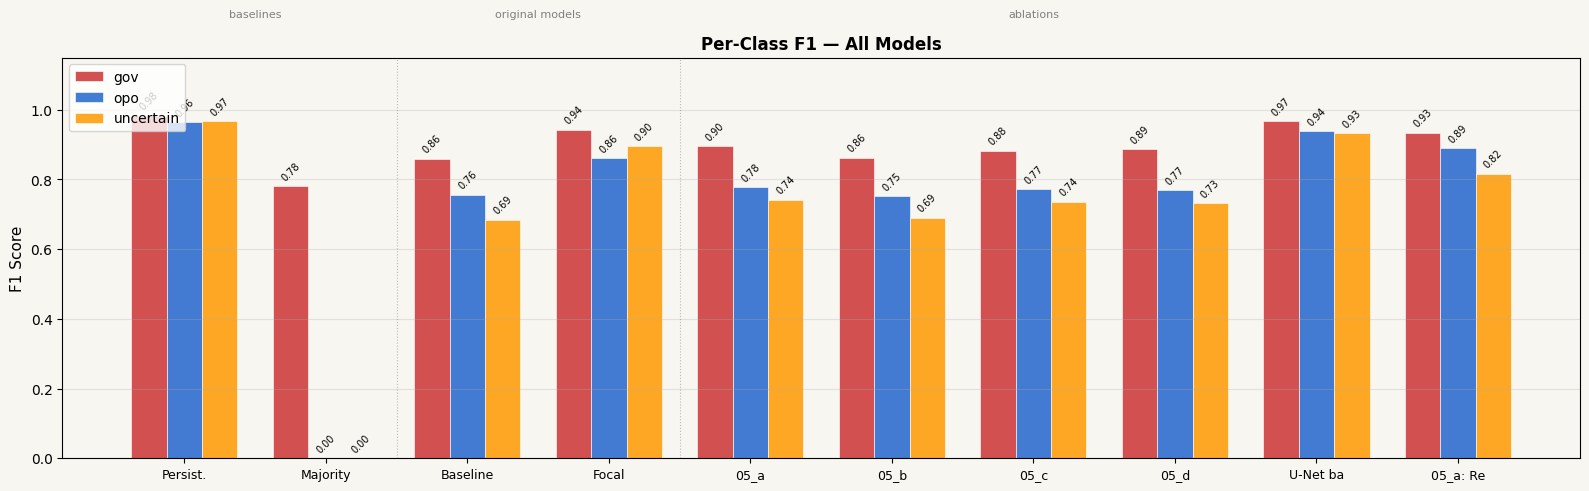

Per-class F1 bar chart saved.


In [7]:
# ── CELL 5b: Per-Class F1 Grouped Bar Chart ──────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

model_order = list(results.keys())
short_labels = {
    'Persistence'               : 'Persist.',
    'Majority (gov)'            : 'Majority',
    'U-Net baseline'            : 'Baseline',
    'U-Net focal mask'          : 'Focal',
    '05_a: Recovered cells'     : '05_a',
    '05_b: Graded CE'           : '05_b',
    '05_c: Masked Dice'         : '05_c',
    '05_d: Recovered+Masked Dice' : '05_d',
}
models_present = [m for m in model_order if m in results]
x_labels = [short_labels.get(m, m[:8]) for m in models_present]

f1_by_class = {cls: [] for cls in CLASS_NAMES}
for m in models_present:
    for cls in CLASS_NAMES:
        f1_by_class[cls].append(results[m]['per_class'][cls]['f1'])

x = np.arange(len(models_present))
width = 0.25
colors = ['#CC3333', '#2266CC', '#FF9900']

fig, ax = plt.subplots(figsize=(max(10, len(models_present) * 1.6), 5), facecolor='#F8F6F0')
ax.set_facecolor('#F8F6F0')
for i, (cls, col) in enumerate(zip(CLASS_NAMES, colors)):
    vals = f1_by_class[cls]
    bars = ax.bar(x + i * width - width, vals, width, label=cls, color=col,
                  edgecolor='white', linewidth=0.5, alpha=0.85)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=9)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_title('Per-Class F1 — All Models', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.axvline(1.5, color='grey', ls=':', alpha=0.5, lw=0.8)  # split baselines / models
ax.axvline(3.5, color='grey', ls=':', alpha=0.5, lw=0.8)  # split original / ablations
ax.text(0.5, 1.10, 'baselines', transform=ax.get_xaxis_transform(), ha='center', fontsize=8, color='grey')
ax.text(2.5, 1.10, 'original models', transform=ax.get_xaxis_transform(), ha='center', fontsize=8, color='grey')
ax.text(6.0, 1.10, 'ablations', transform=ax.get_xaxis_transform(), ha='center', fontsize=8, color='grey')
plt.tight_layout()
fig.savefig(REPORTS / 'fig_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Per-class F1 bar chart saved.')


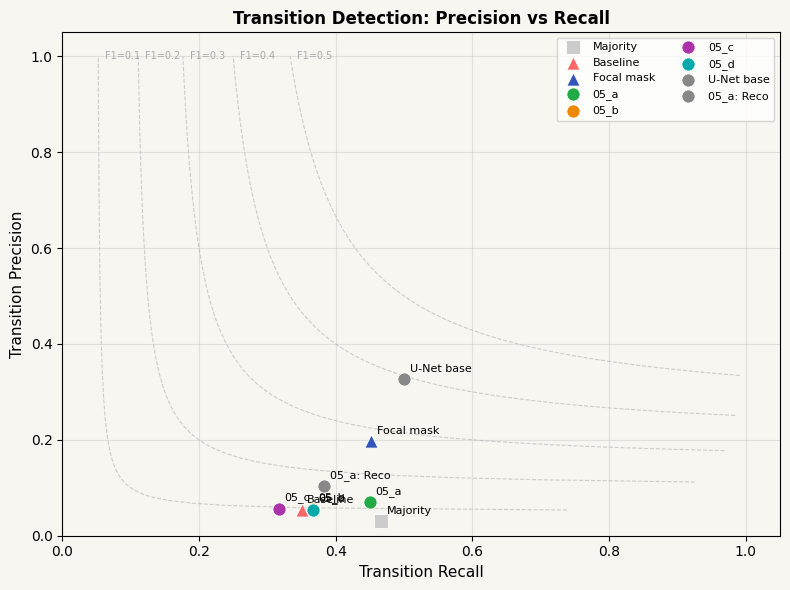

Transition PR scatter saved.


In [8]:
# ── CELL 5c: Transition Precision-Recall Scatter Plot ────────────────────────
import matplotlib.pyplot as plt
import numpy as np

models_present = [m for m in results.keys()]
colors_map = {
    'Persistence'               : '#999999',
    'Majority (gov)'            : '#CCCCCC',
    'U-Net baseline'            : '#FF6666',
    'U-Net focal mask'          : '#3355BB',
    '05_a: Recovered cells'     : '#22AA44',
    '05_b: Graded CE'           : '#EE8800',
    '05_c: Masked Dice'         : '#AA33AA',
    '05_d: Recovered+Masked Dice' : '#00AAAA',
}
markers_map = {
    'Persistence': 's', 'Majority (gov)': 's',
    'U-Net baseline': '^', 'U-Net focal mask': '^',
}

fig, ax = plt.subplots(figsize=(8, 6), facecolor='#F8F6F0')
ax.set_facecolor('#F8F6F0')

# F1 iso-curves
for f1_iso in [0.1, 0.2, 0.3, 0.4, 0.5]:
    p_range = np.linspace(f1_iso / (2 - f1_iso) + 0.001, 1.0, 200)
    r_range = f1_iso * p_range / (2 * p_range - f1_iso)
    valid = (r_range >= 0) & (r_range <= 1)
    ax.plot(r_range[valid], p_range[valid], '--', color='#CCCCCC', lw=0.8, zorder=0)
    ax.text(r_range[valid][-1] + 0.01, p_range[valid][-1],
            f'F1={f1_iso}', fontsize=7, color='#AAAAAA', va='center')

for m in models_present:
    rec = results[m].get('transition_recall', np.nan)
    pre = results[m].get('transition_prec', np.nan)
    if np.isnan(rec) or np.isnan(pre): continue
    col = colors_map.get(m, '#888888')
    mrk = markers_map.get(m, 'o')
    short = {'Persistence': 'Persist.', 'Majority (gov)': 'Majority',
             'U-Net baseline': 'Baseline', 'U-Net focal mask': 'Focal mask',
             '05_a: Recovered cells': '05_a', '05_b: Graded CE': '05_b',
             '05_c: Masked Dice': '05_c', '05_d: Recovered+Masked Dice': '05_d'}.get(m, m[:10])
    ax.scatter(rec, pre, color=col, marker=mrk, s=90, zorder=5, label=short,
               edgecolors='white', linewidths=0.6)
    ax.annotate(short, (rec, pre), fontsize=8, ha='left', va='bottom',
                xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('Transition Recall', fontsize=11)
ax.set_ylabel('Transition Precision', fontsize=11)
ax.set_title('Transition Detection: Precision vs Recall', fontsize=12, fontweight='bold')
ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(REPORTS / 'fig_transition_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print('Transition PR scatter saved.')


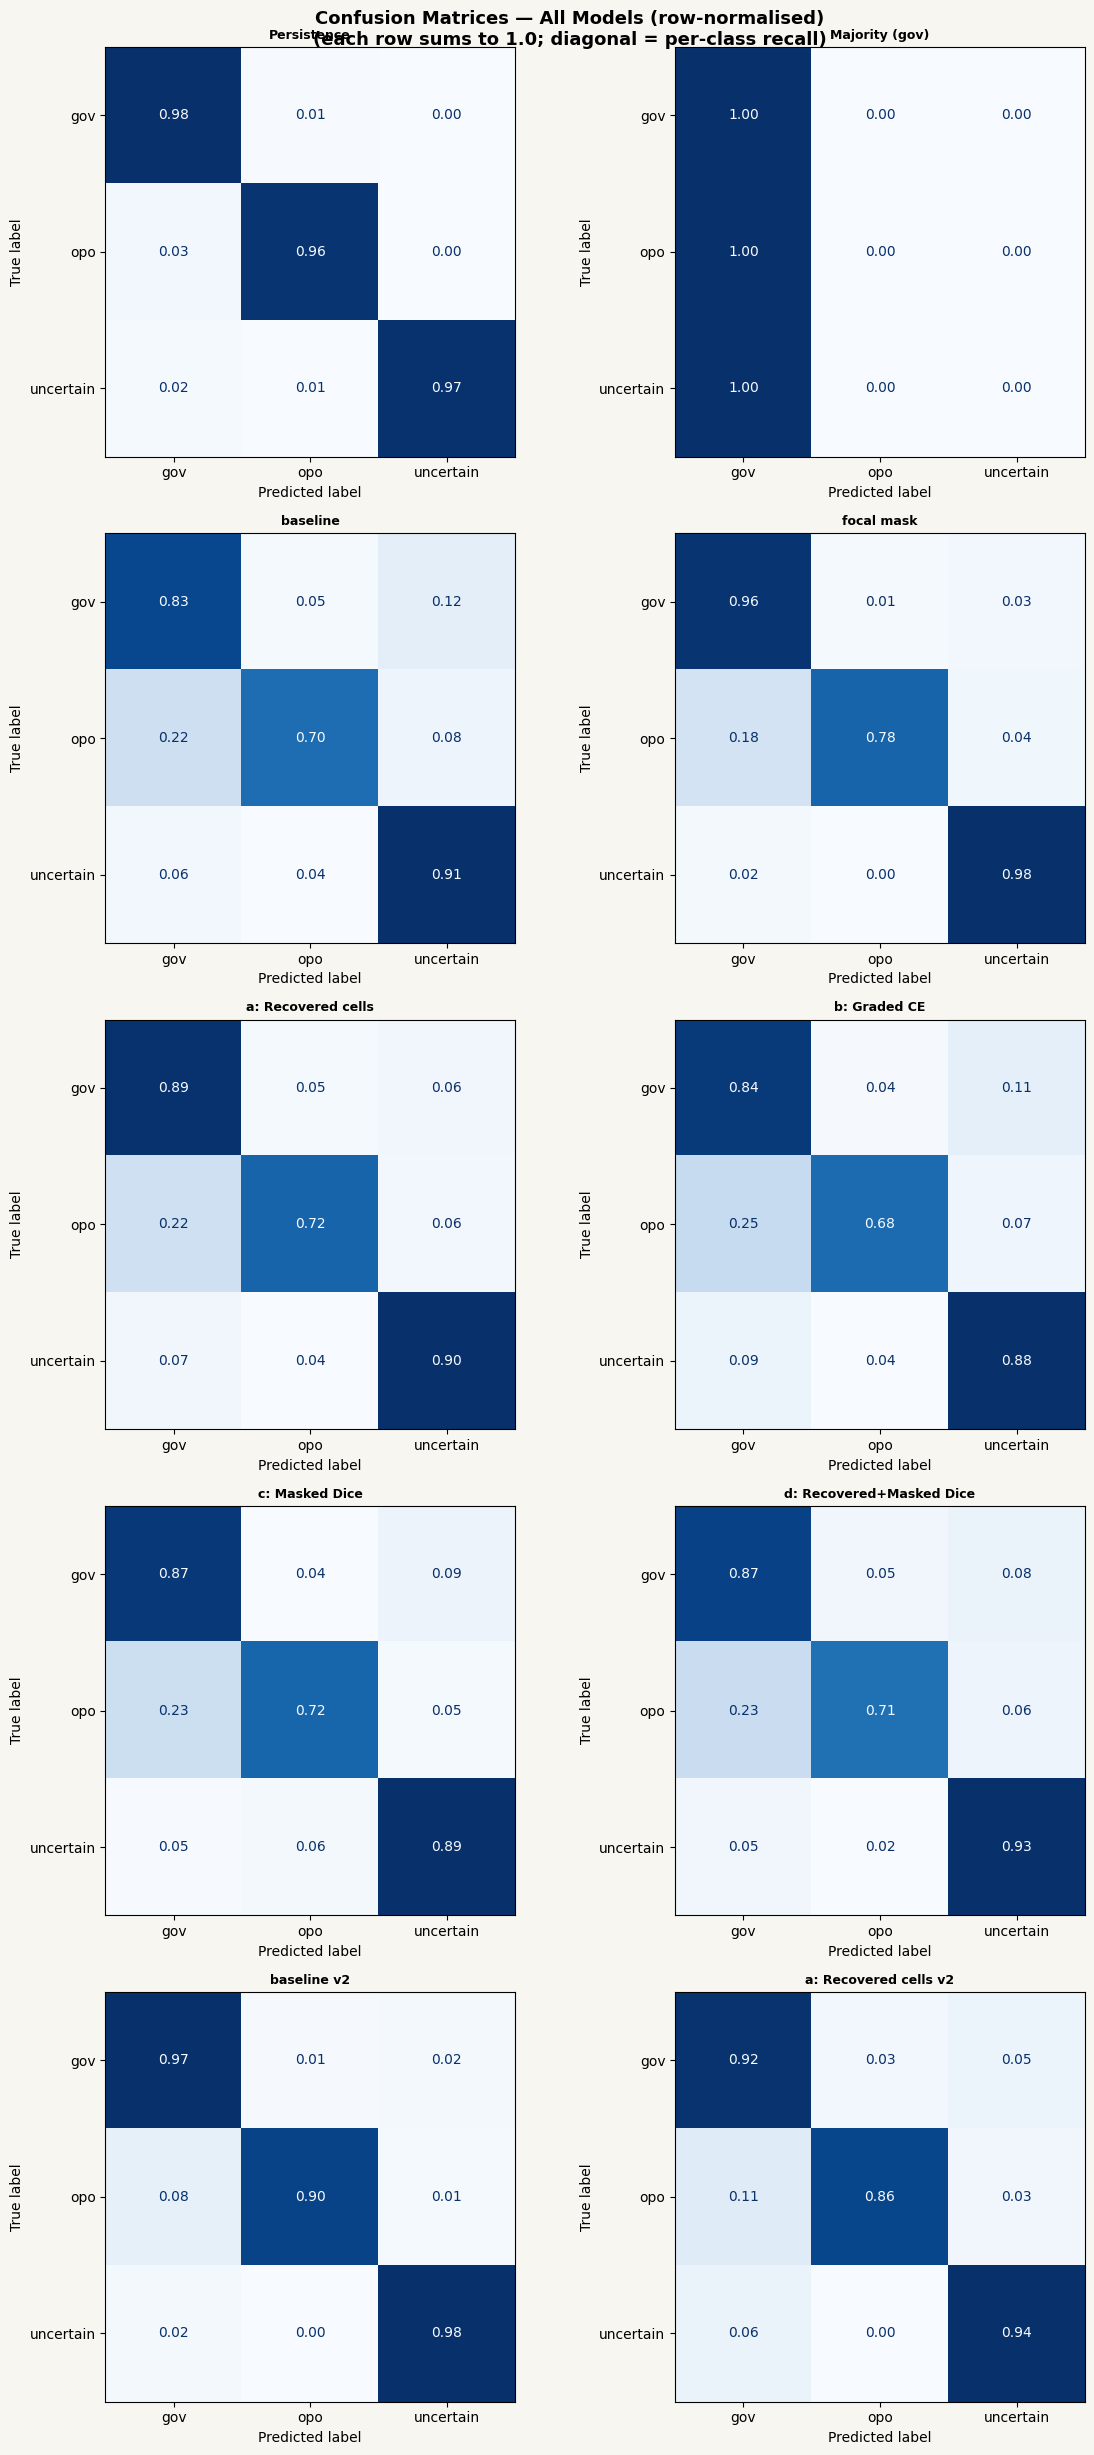

Confusion matrices saved (10 models, 5×2 grid).


In [9]:
# ── CELL 6: Confusion Matrix Heatmaps ───────────────────────────────────────
all_model_keys = list(results.keys())
n_models = len(all_model_keys)

N_COLS = 2
N_ROWS = int(np.ceil(n_models / N_COLS))

fig, axes = plt.subplots(N_ROWS, N_COLS,
                          figsize=(12, 5 * N_ROWS),
                          facecolor='#F8F6F0', squeeze=False)
fig.suptitle('Confusion Matrices — All Models (row-normalised)\n'
             '(each row sums to 1.0; diagonal = per-class recall)',
             fontsize=13, fontweight='bold')

def get_yt_yp(model_label):
    if model_label == 'Persistence':
        sub = gt_val.dropna(subset=['prev_label'])
        return sub['label_int'].astype(int).values, sub['prev_label'].astype(int).values
    elif model_label == 'Majority (gov)':
        return gt_val['label_int'].astype(int).values, np.zeros(len(gt_val), dtype=int)
    else:
        pred_df = model_preds[model_label]
        y_t, y_p, _ = merge_preds(gt_val, pred_df)
        return y_t.astype(int), y_p.astype(int)

for idx, model_label in enumerate(all_model_keys):
    row_i, col_i = divmod(idx, N_COLS)
    ax = axes[row_i, col_i]
    ax.set_facecolor('#F8F6F0')
    y_t_i, y_p_i = get_yt_yp(model_label)
    cm      = confusion_matrix(y_t_i, y_p_i, labels=[0,1,2])
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
    ConfusionMatrixDisplay(cm_norm, display_labels=CLASS_NAMES).plot(
        ax=ax, cmap='Blues', colorbar=False, values_format='.2f')
    short = model_label.replace('U-Net ', '').replace('05_', '')
    ax.set_title(short, fontsize=9, fontweight='bold')

# Hide unused panels
for idx in range(n_models, N_ROWS * N_COLS):
    row_i, col_i = divmod(idx, N_COLS)
    axes[row_i, col_i].set_visible(False)

plt.tight_layout()
fig.savefig(REPORTS / 'eval_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Confusion matrices saved ({n_models} models, {N_ROWS}×{N_COLS} grid).')


Showcase month: 2025-10  (9 ground-truth transitions)


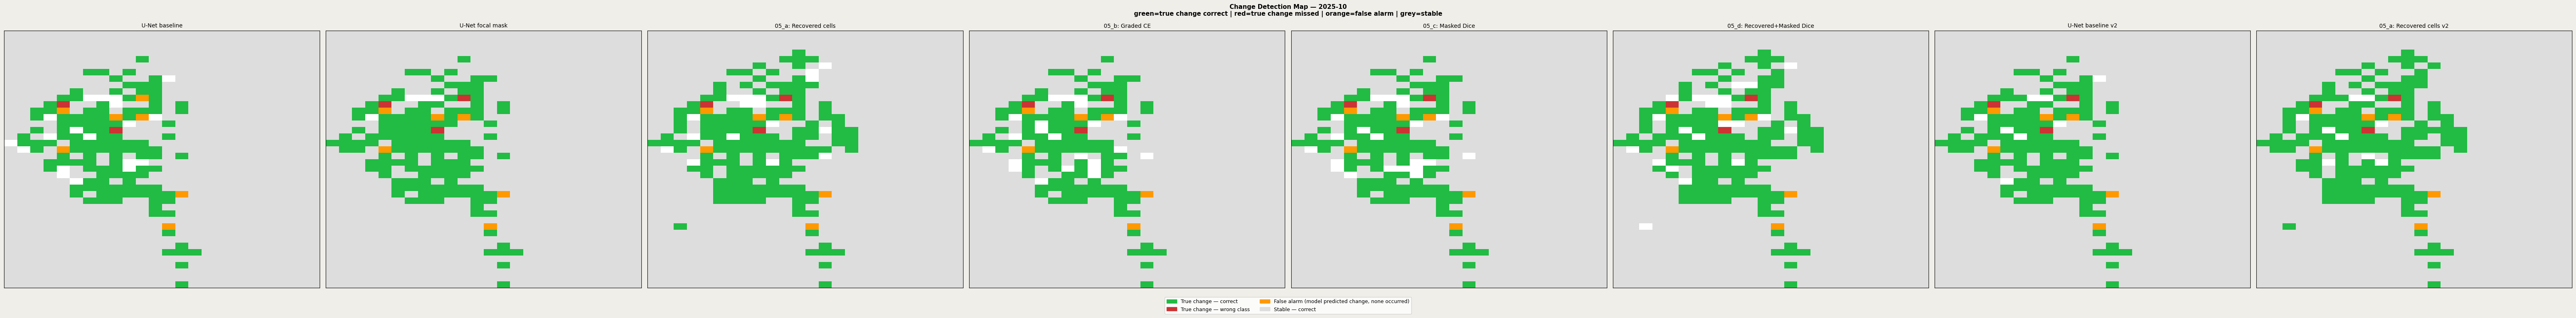

Change map saved.

Cells with >=1 change(s) in val window: 20  |  Showing 5


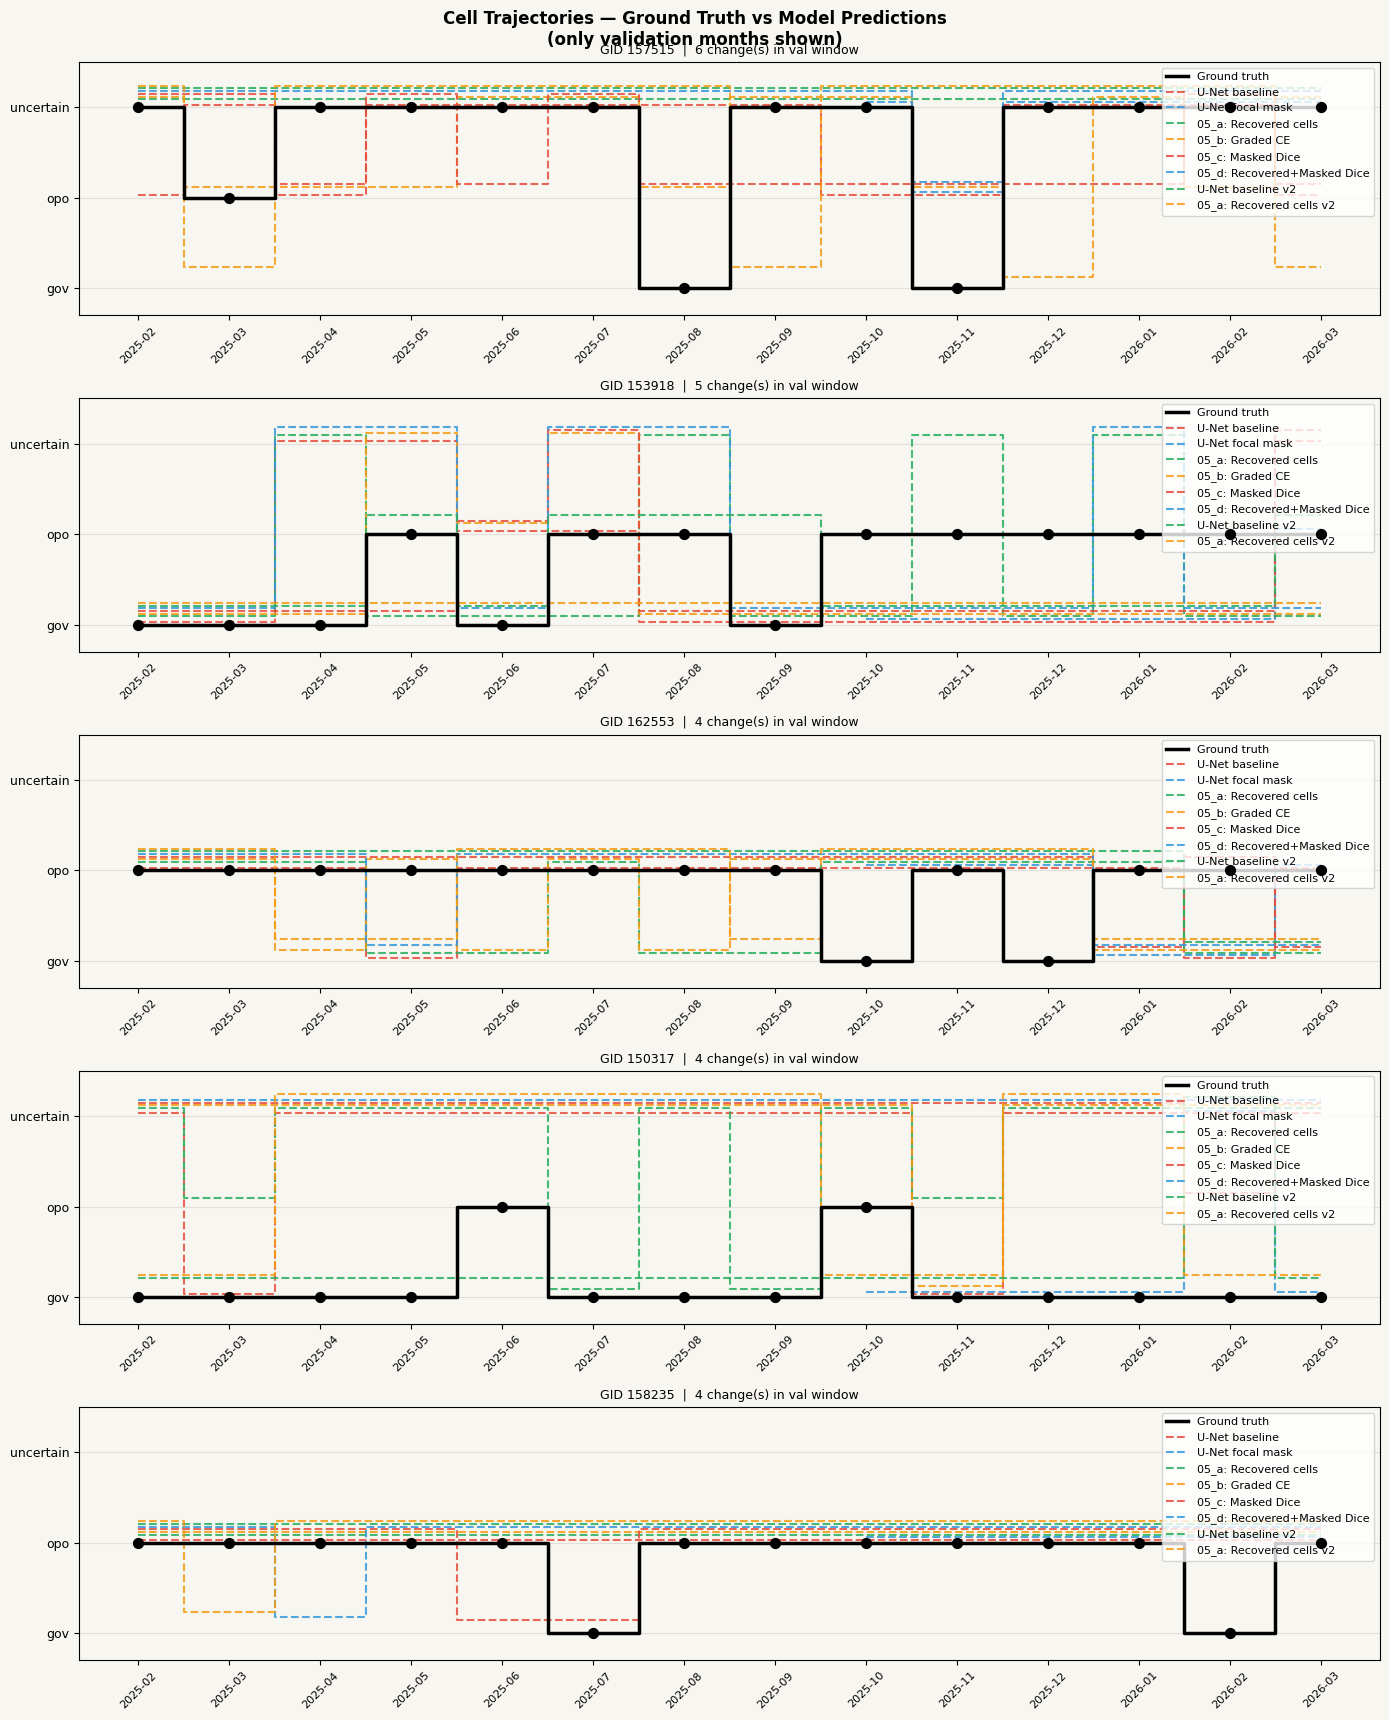

Trajectory plots saved.


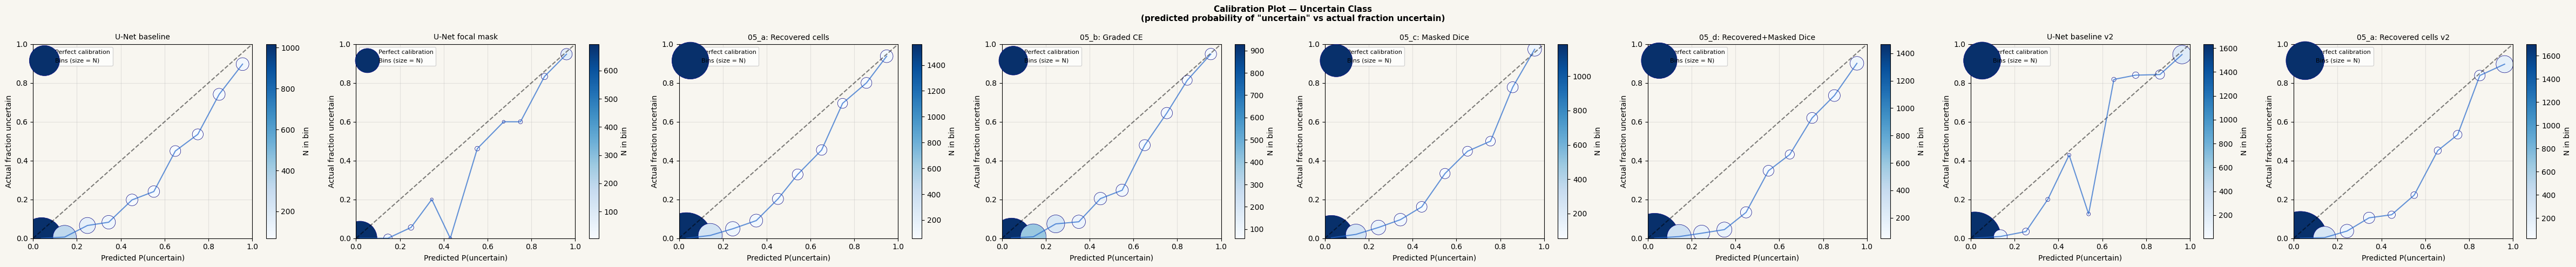

Calibration plot saved.


In [10]:
# ── CELL 7: Visual Diagnostics ───────────────────────────────────────────────

# ── 7.1 Predicted vs actual change map for one held-out month ─────────────────
# Choose the val month with the most ground-truth transitions.

val_months = sorted(gt_val['year_month'].unique())

# Count transitions per month (where prev_label exists and differs from label_int)
gt_cd = gt_val.dropna(subset=['prev_label']).copy()
gt_cd['is_trans'] = gt_cd['label_int'] != gt_cd['prev_label']
trans_by_month = gt_cd.groupby('year_month')['is_trans'].sum()
showcase_month = trans_by_month.idxmax()
print(f'Showcase month: {showcase_month}  '
      f'({int(trans_by_month[showcase_month])} ground-truth transitions)')

# Build rasters for this month
RASTER_H_PAD = int(np.ceil(RASTER_H / 8) * 8)
RASTER_W_PAD = int(np.ceil(RASTER_W / 8) * 8)

def build_change_raster(month, pred_col_name, pred_vals_df):
    """
    Build a raster where:
      -1 = no label
       0 = stable (true and predicted agree it did not change)
       1 = true change, model correct
       2 = true change, model wrong
       3 = false alarm (model predicted change, no actual change)
    """
    raster = np.full((RASTER_H_PAD, RASTER_W_PAD), -1, dtype=float)
    month_gt   = gt_cd[gt_cd['year_month'] == month]
    month_pred = pred_vals_df[pred_vals_df['year_month'] == month]
    pred_lookup_m = month_pred.set_index('priogrid_gid')['pred_class_int'].to_dict()

    for _, row in month_gt.iterrows():
        gid = int(row['priogrid_gid'])
        if gid not in gid_to_rc: continue
        if gid not in pred_lookup_m: continue
        lr, lc = gid_to_rc[gid]['local_row'], gid_to_rc[gid]['local_col']
        yt   = int(row['label_int'])
        yprev = int(row['prev_label'])
        yp   = int(pred_lookup_m[gid])
        true_changed  = (yt != yprev)
        model_changed = (yp != yprev)
        if true_changed and (yp == yt):
            raster[lr, lc] = 1   # true change, correct
        elif true_changed and (yp != yt):
            raster[lr, lc] = 2   # true change, wrong
        elif (not true_changed) and model_changed:
            raster[lr, lc] = 3   # false alarm
        else:
            raster[lr, lc] = 0   # stable, model agrees
    return raster

# Build for available models (skip baselines for this plot)
change_rasters = {}
for model_label, pred_df in model_preds.items():
    cr = build_change_raster(showcase_month, 'pred_class_int', pred_df)
    change_rasters[model_label] = cr

if change_rasters:
    cmap_change = mcolors.ListedColormap(['#DDDDDD','#22BB44','#CC3333','#FF9900','#FFFFFF'])
    norm_change = mcolors.BoundaryNorm([-1.5,-0.5,0.5,1.5,2.5,3.5], cmap_change.N)

    fig, axes = plt.subplots(1, len(change_rasters),
                              figsize=(8*len(change_rasters), 8), facecolor='#F0EEE8')
    if len(change_rasters) == 1: axes = [axes]
    fig.suptitle(f'Change Detection Map — {showcase_month}\n'
                 f'green=true change correct | red=true change missed | orange=false alarm | grey=stable',
                 fontsize=11, fontweight='bold')

    for ax, (ml, cr) in zip(axes, change_rasters.items()):
        ax.imshow(cr, cmap=cmap_change, norm=norm_change, origin='lower', aspect='auto')
        ax.set_title(ml, fontsize=10); ax.set_xticks([]); ax.set_yticks([])

    patches = [
        mpatches.Patch(color='#22BB44', label='True change — correct'),
        mpatches.Patch(color='#CC3333', label='True change — wrong class'),
        mpatches.Patch(color='#FF9900', label='False alarm (model predicted change, none occurred)'),
        mpatches.Patch(color='#DDDDDD', label='Stable — correct'),
    ]
    fig.legend(handles=patches, loc='lower center', ncol=2,
               fontsize=9, bbox_to_anchor=(0.5, 0.01))
    plt.tight_layout(rect=[0, 0.08, 1, 1])
    fig.savefig(REPORTS / f'eval_change_map_{showcase_month}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Change map saved.')
else:
    print('No neural model prediction CSVs loaded — skipping change map.')


# ── 7.2 Cell trajectory plots ─────────────────────────────────────────────────
# Find cells with the most label changes in the validation window.

change_counts = gt_cd.groupby('priogrid_gid')['is_trans'].sum().sort_values(ascending=False)
min_changes   = 1   # lower to 1 if <5 cells have >=2 changes
cand_gids     = change_counts[change_counts >= 2].index.tolist()
if len(cand_gids) < 5:
    min_changes = 1
    cand_gids   = change_counts[change_counts >= 1].index.tolist()
showcase_gids = cand_gids[:5]

print(f'\nCells with >={min_changes} change(s) in val window: {len(cand_gids)}'
      f'  |  Showing {len(showcase_gids)}')

if showcase_gids:
    n_rows = len(showcase_gids)
    fig, axes = plt.subplots(n_rows, 1,
                              figsize=(14, 3.5 * n_rows), facecolor='#F8F6F0')
    if n_rows == 1: axes = [axes]
    fig.suptitle('Cell Trajectories — Ground Truth vs Model Predictions\n'
                 '(only validation months shown)', fontsize=12, fontweight='bold')

    CLASS_COLORS = {'gov': '#CC3333', 'opo': '#2266CC', 'uncertain': '#FF9900'}
    CLASS_JITTER = {'gov': 0.0, 'opo': 0.05, 'uncertain': -0.05}

    for ax, gid in zip(axes, showcase_gids):
        ax.set_facecolor('#F8F6F0')
        gid_gt = gt_val[gt_val['priogrid_gid'] == gid].sort_values('year_month')

        # Ground truth
        ax.step(gid_gt['year_month'], gid_gt['label_int'],
                where='mid', color='black', lw=2.5, label='Ground truth', zorder=5)
        ax.scatter(gid_gt['year_month'], gid_gt['label_int'],
                   color='black', s=50, zorder=6)

        # Model predictions
        for i, (ml, pred_df) in enumerate(model_preds.items()):
            gid_pred = pred_df[pred_df['priogrid_gid'] == gid].sort_values('year_month')
            if len(gid_pred) == 0: continue
            color = ['#E74C3C','#3498DB','#27AE60','#F39C12'][i % 4]
            ax.step(gid_pred['year_month'], gid_pred['pred_class_int'] + 0.03*(i+1),
                    where='mid', color=color, lw=1.5, linestyle='--', label=ml, alpha=0.85)

        ax.set_yticks([0, 1, 2])
        ax.set_yticklabels(['gov', 'opo', 'uncertain'], fontsize=9)
        ax.set_ylim(-0.3, 2.5)
        ax.set_title(f'GID {gid}  |  {int(change_counts.get(gid, 0))} change(s) in val window',
                     fontsize=9)
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    fig.savefig(REPORTS / 'eval_cell_trajectories.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Trajectory plots saved.')
else:
    print('No cells with changes in validation window — skipping trajectory plots.')


# ── 7.3 Calibration plot for uncertain class ──────────────────────────────────
# Requires prob_uncertain column (only U-Net models have this).

calib_models = {ml: probs for ml, probs in model_probs.items()
                if 'prob_uncertain' in probs.columns}

if calib_models:
    fig, axes = plt.subplots(1, len(calib_models),
                              figsize=(6*len(calib_models), 5), facecolor='#F8F6F0')
    if len(calib_models) == 1: axes = [axes]
    fig.suptitle('Calibration Plot — Uncertain Class\n'
                 '(predicted probability of "uncertain" vs actual fraction uncertain)',
                 fontsize=11, fontweight='bold')

    N_BINS = 10

    for ax, (ml, prob_df) in zip(axes, calib_models.items()):
        # Merge with ground truth
        merged_cal = gt_val[['priogrid_gid','year_month','label_int']].merge(
            prob_df[['priogrid_gid','year_month','prob_uncertain']],
            on=['priogrid_gid','year_month'], how='inner'
        )
        merged_cal['actual_uncertain'] = (merged_cal['label_int'] == 2).astype(int)

        # Bin by predicted probability
        merged_cal['bin'] = pd.cut(merged_cal['prob_uncertain'],
                                   bins=N_BINS, labels=False, include_lowest=True)
        bin_stats = merged_cal.groupby('bin').agg(
            mean_prob=('prob_uncertain', 'mean'),
            actual_frac=('actual_uncertain', 'mean'),
            count=('actual_uncertain', 'count')
        ).dropna()

        ax.set_facecolor('#F8F6F0')
        ax.plot([0,1],[0,1], 'k--', alpha=0.5, label='Perfect calibration')
        sc = ax.scatter(bin_stats['mean_prob'], bin_stats['actual_frac'],
                        s=bin_stats['count']*3, c=bin_stats['count'],
                        cmap='Blues', edgecolors='navy', linewidths=0.5,
                        label='Bins (size = N)')
        ax.plot(bin_stats['mean_prob'], bin_stats['actual_frac'],
                color='#2266CC', lw=1.5, alpha=0.7)
        plt.colorbar(sc, ax=ax, label='N in bin')
        ax.set_xlabel('Predicted P(uncertain)'); ax.set_ylabel('Actual fraction uncertain')
        ax.set_title(ml, fontsize=10)
        ax.set_xlim(0,1); ax.set_ylim(0,1)
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fig.savefig(REPORTS / 'eval_uncertain_calibration.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Calibration plot saved.')
else:
    print('No probability outputs available — skipping calibration plot.')


In [11]:
# ── CELL 8: Plain-Language Summary ───────────────────────────────────────────
# This paragraph will be quoted in the slide / thesis.

print('=' * 80)
print('SUMMARY — What these numbers mean')
print('=' * 80)

def fmt(v, pct=True):
    if isinstance(v, float) and np.isnan(v): return 'N/A'
    return f'{v*100:.1f}%' if pct else f'{v:.3f}'

p = results.get('Persistence', {})
g = results.get('Majority (gov)', {})
unet_key = next((k for k in results if 'U-Net baseline' in k or 'baseline' in k.lower()
                 and 'focal' not in k.lower()), None)
focal_key = next((k for k in results if 'focal' in k.lower()), None)

lines = []
lines.append(
    f'On the {eval_df["N"].max():,}-cell-month validation set (Oct 2025 – Mar 2026), '
    f'the persistence baseline — predicting that each cell stays at its previous '
    f'month label — scores a macro F1 of {fmt(p.get("macro_f1"), pct=False)} and '
    f'{fmt(p.get("raw_acc"))} raw accuracy but, by construction, '
    f'achieves zero transition recall: it never predicts a control change. '
)

lines.append(
    f'The majority-class baseline (always predict government) scores '
    f'{fmt(g.get("raw_acc"))} accuracy — reflecting the {fmt(gov_share)} government '
    f'share in the validation set — but only {fmt(g.get("macro_f1"), pct=False)} '
    f'macro F1 because it never identifies opposition or contested cells. '
)

if unet_key:
    u = results[unet_key]
    lines.append(
        f'The U-Net baseline achieves {fmt(u.get("macro_f1"), pct=False)} macro F1 '
        f'and {fmt(u.get("raw_acc"))} accuracy. '
        f'Transition recall is {fmt(u.get("transition_recall"))} '
        f'({int(u.get("n_transitions",0))} actual changes in the validation window). '
    )
    if u.get('transition_recall', 0) > 0:
        lines.append(
            f'The U-Net does detect some control changes, outperforming persistence '
            f'on the dynamic subset. '
        )
    else:
        lines.append(
            f'However, the U-Net transition recall is zero or undefined, indicating '
            f'the model has not learned to detect control changes — it learns the '
            f'spatial prior but not temporal dynamics. This should be acknowledged '
            f'openly in the thesis. '
        )

if focal_key:
    f2 = results[focal_key]
    u2 = results.get(unet_key, {})
    delta_tr = (f2.get('transition_recall', np.nan) or np.nan) - (u2.get('transition_recall', np.nan) or np.nan)
    delta_f1 = f2.get('macro_f1', np.nan) - u2.get('macro_f1', np.nan)
    if not np.isnan(delta_tr):
        direction = 'improves' if delta_tr > 0 else 'does not improve'
        lines.append(
            f'The focal-mask model {direction} transition recall by {abs(delta_tr)*100:.1f}pp '
            f'relative to the baseline U-Net, with a macro F1 change of {delta_f1*100:+.1f}pp. '
        )

# ── Ablation experiment summaries ────────────────────────────────────────────
ablation_labels = ['05_a: Recovered cells', '05_b: Graded CE',
                   '05_c: Masked Dice', '05_d: Recovered+Masked Dice']
ablation_names  = {
    '05_a: Recovered cells'       : 'Recovering the 36 dropped cells',
    '05_b: Graded CE'             : 'Graded CE weights (1.0/0.7/0.1)',
    '05_c: Masked Dice'           : 'Masking Dice to in-Myanmar pixels',
    '05_d: Recovered+Masked Dice' : 'Combined: recovered cells + masked Dice',
}
if focal_key in results:
    for abl_key in ablation_labels:
        if abl_key not in results: continue
        a = results[abl_key]
        baseline_f1 = results[focal_key].get('macro_f1', np.nan)
        baseline_tr = results[focal_key].get('transition_recall', np.nan)
        delta_f1 = a.get('macro_f1', np.nan) - baseline_f1
        delta_tr = (a.get('transition_recall', np.nan) or np.nan) - (baseline_tr or np.nan)
        sign_f1  = '+' if not np.isnan(delta_f1) and delta_f1 >= 0 else ''
        sign_tr  = '+' if not np.isnan(delta_tr) and delta_tr >= 0 else ''
        label    = ablation_names.get(abl_key, abl_key)
        tr_str   = f'{sign_tr}{delta_tr*100:.1f}pp' if not np.isnan(delta_tr) else 'N/A'
        f1_str   = f'{sign_f1}{delta_f1*100:.1f}pp' if not np.isnan(delta_f1) else 'N/A'
        lines.append(
            f'{label}: macro F1 vs focal-mask baseline: {f1_str}; '
            f'transition recall change: {tr_str}. '
        )

lines.append(
    f'Subset analyses show that the {(gt_val["wiki_changed_recent"]==True).sum()} '
    f'rows with a Wikipedia edit in the ±1-month window (transition window) are the '
    f'hardest subset — these are the ground-truth transition events. '
    f'The {(gt_val["acled_side"] != "none").sum()} ACLED-enriched rows '
    f'are too few ({(gt_val["acled_side"] != "none").mean()*100:.1f}% of val) '
    f'to draw strong conclusions about whether ACLED integration helps. '
)

summary = ' '.join(lines)
print()
print(summary)
print()

# Save summary as a text file for easy copy-paste
(DOCS / 'eval_summary.txt').write_text(summary)
print(f'Summary saved to docs/eval_summary.txt')
print(f'Evaluation table saved to docs/eval_table.csv')


SUMMARY — What these numbers mean

On the 2,590-cell-month validation set (Oct 2025 – Mar 2026), the persistence baseline — predicting that each cell stays at its previous month label — scores a macro F1 of 0.972 and 97.7% raw accuracy but, by construction, achieves zero transition recall: it never predicts a control change.  The majority-class baseline (always predict government) scores 64.1% accuracy — reflecting the 64.1% government share in the validation set — but only 0.260 macro F1 because it never identifies opposition or contested cells.  The U-Net baseline achieves 0.767 macro F1 and 80.6% accuracy. Transition recall is 35.0% (60 actual changes in the validation window).  The U-Net does detect some control changes, outperforming persistence on the dynamic subset.  The focal-mask model improves transition recall by 10.2pp relative to the baseline U-Net, with a macro F1 change of +13.3pp.  Recovering the 36 dropped cells: macro F1 vs focal-mask baseline: -9.5pp; transition reca

Cells with >=1 transition in val window: 24
Total val transitions: 60
  2025-02: 0
  2025-03: 1
  2025-04: 4
  2025-05: 5
  2025-06: 5
  2025-07: 5
  2025-08: 3
  2025-09: 6
  2025-10: 9
  2025-11: 5
  2025-12: 2
  2026-01: 5
  2026-02: 7
  2026-03: 3
Selected months: ['2025-06', '2025-08', '2025-09', '2025-11', '2026-03']


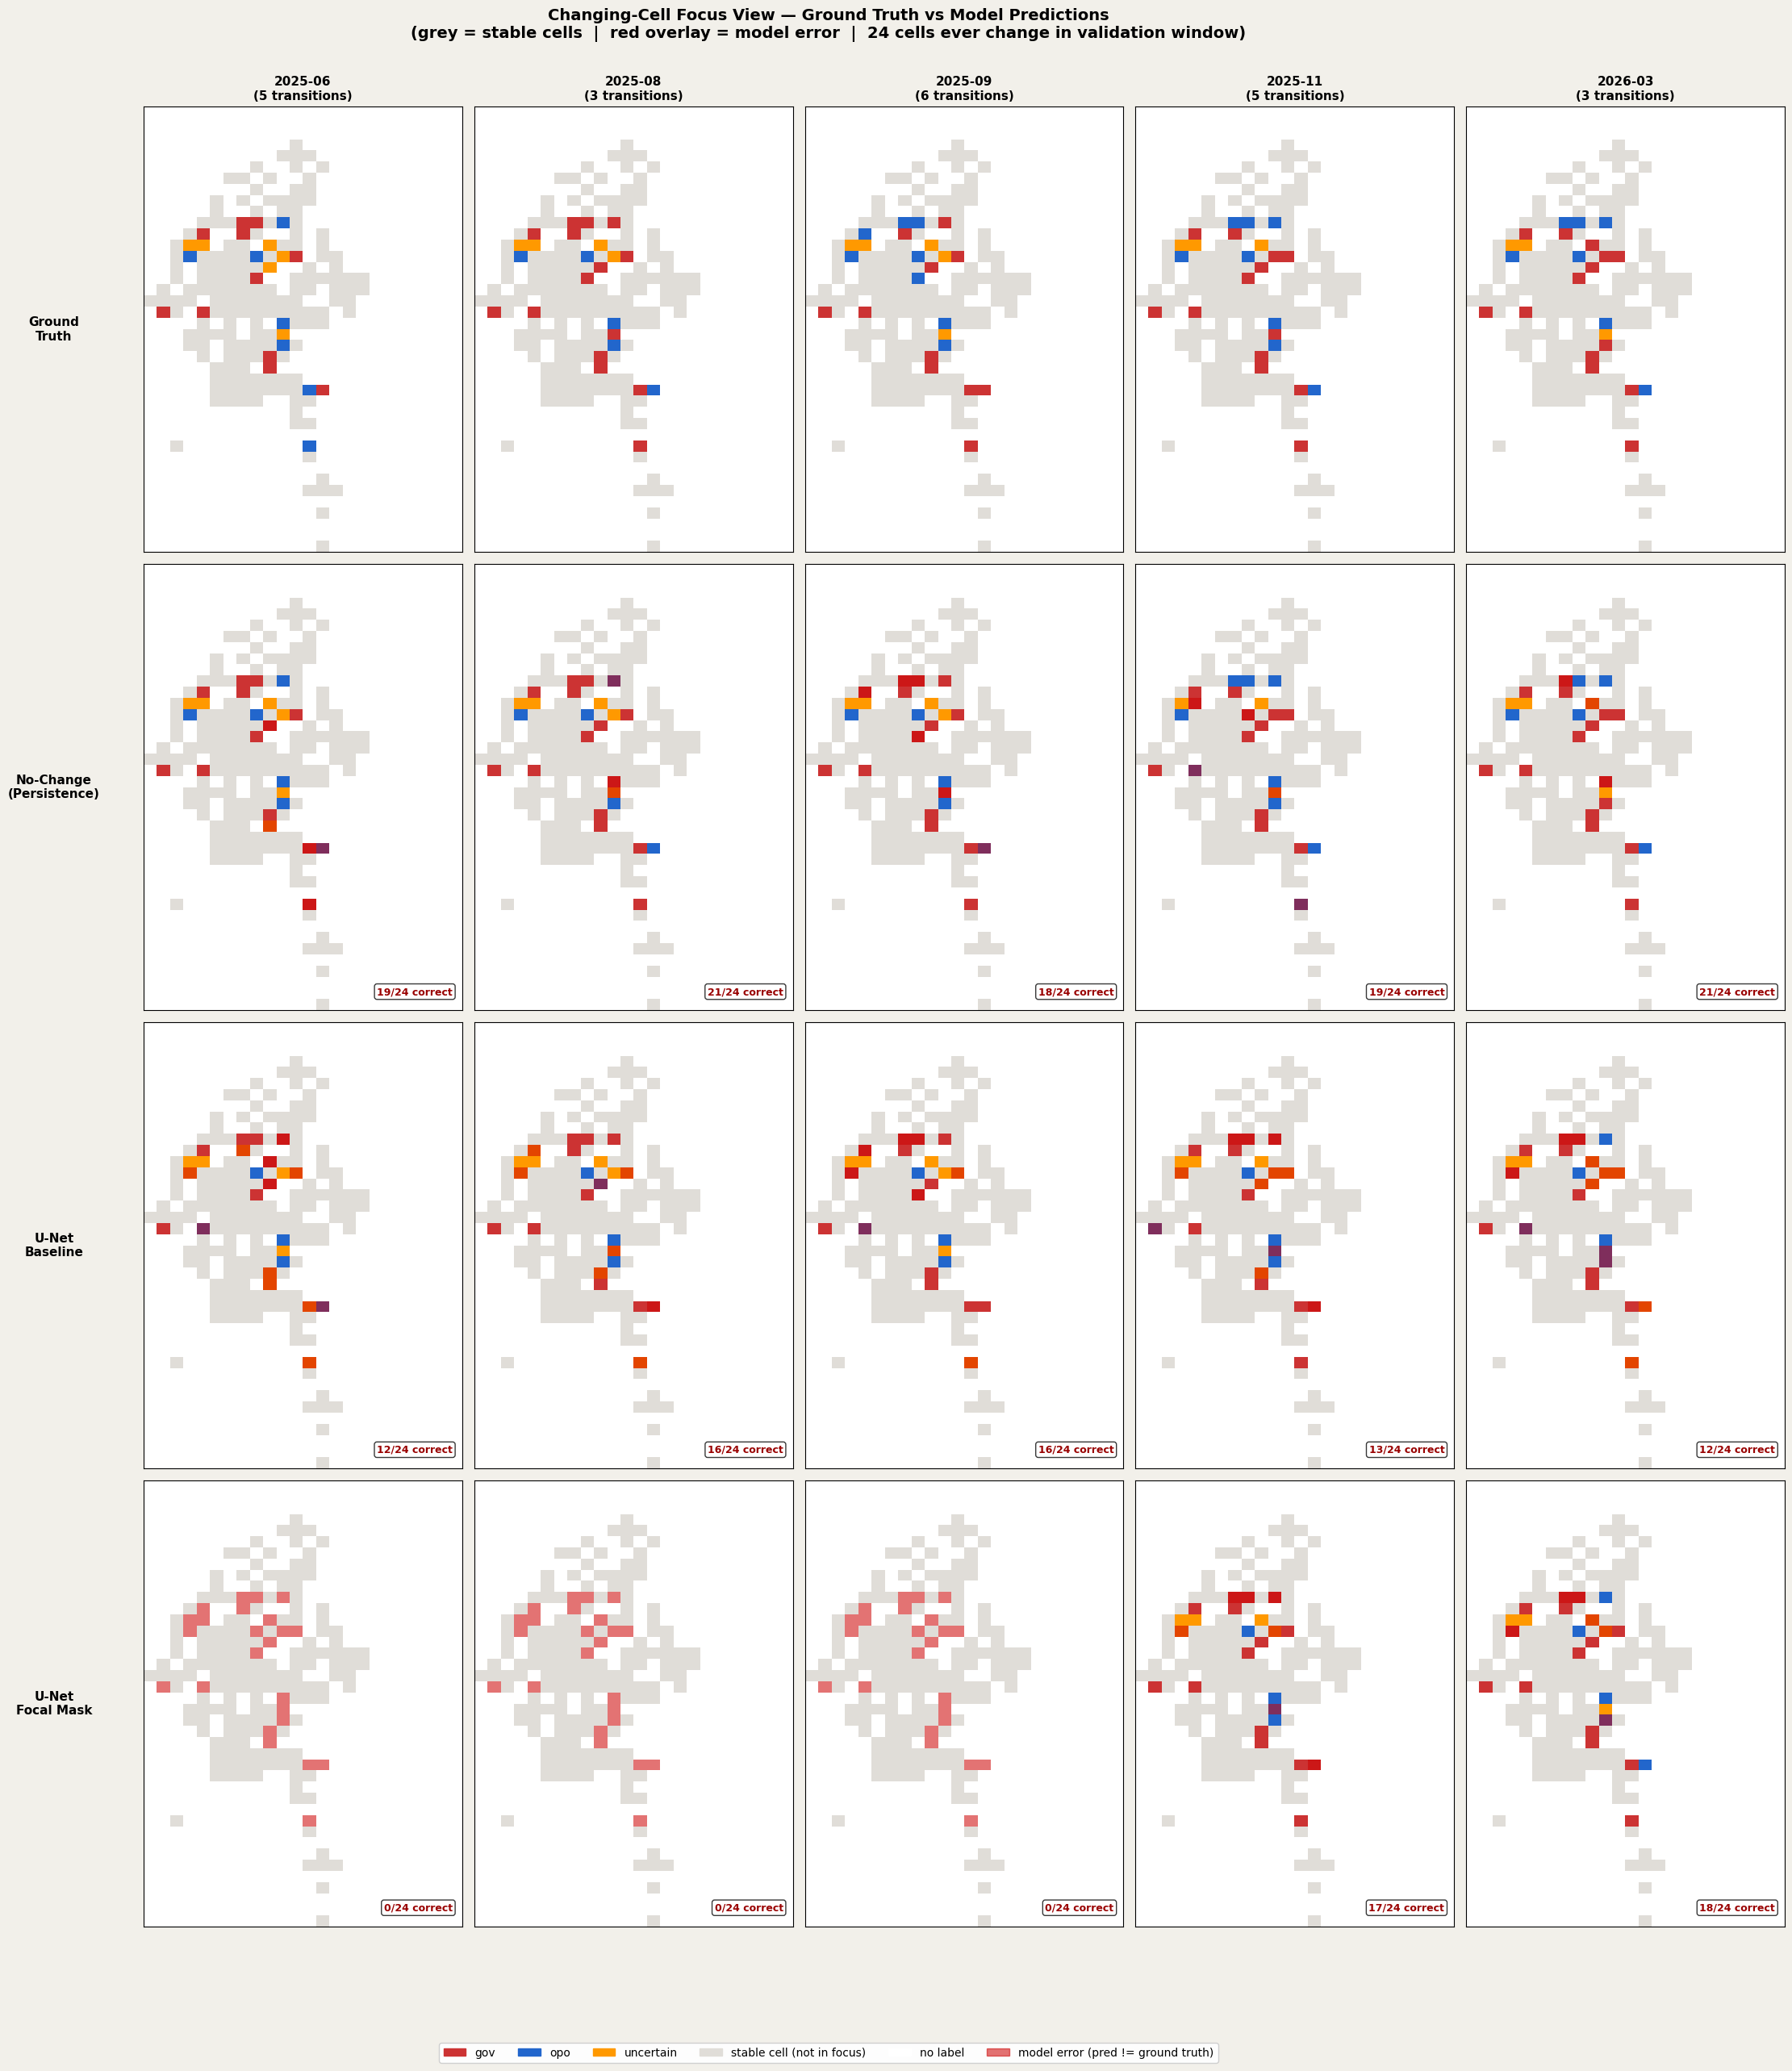

Saved: eval_focus_view_changing_cells.png


In [12]:
# ── CELL 9: Focus View — Cells That Change, 5 Months × 3 Models ─────────────
# For each of 5 randomly selected validation months, show 4 panels:
#   Ground Truth | Persistence | U-Net Baseline | U-Net Focal Mask
# Only cells that change at any point in the validation window are highlighted.
# Stable cells shown in grey. Red overlay marks model errors on changing cells.

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import pandas as pd

# ── 9.1 Cells that change at any point in the validation window ───────────────
gt_cd = gt_val.dropna(subset=['prev_label']).copy()
gt_cd['is_trans'] = (gt_cd['label_int'] != gt_cd['prev_label']).astype(int)
changing_gids_val = set(gt_cd[gt_cd['is_trans'] == 1]['priogrid_gid'].unique())
print(f'Cells with >=1 transition in val window: {len(changing_gids_val)}')
print(f'Total val transitions: {int(gt_cd["is_trans"].sum())}')
for m, cnt in gt_cd.groupby('year_month')['is_trans'].sum().items():
    print(f'  {m}: {int(cnt)}')

# ── 9.2 Select 5 months ───────────────────────────────────────────────────────
rng = np.random.default_rng(20269999)
val_months_all = sorted(gt_val['year_month'].unique())
n_pick = min(5, len(val_months_all))
selected_months = sorted(rng.choice(val_months_all, size=n_pick, replace=False).tolist())
print(f'Selected months: {selected_months}')

# ── 9.3 Raster dimensions ─────────────────────────────────────────────────────
PAD_H = int(np.ceil(RASTER_H / 8) * 8)
PAD_W = int(np.ceil(RASTER_W / 8) * 8)

# ── 9.4 Colourmaps ────────────────────────────────────────────────────────────
# -2=unlabelled(white) -1=stable(grey) 0=gov 1=opo 2=uncertain
CMAP_FOCUS = mcolors.ListedColormap(['#FFFFFF', '#E0DDD8', '#CC3333', '#2266CC', '#FF9900'])
NORM_FOCUS = mcolors.BoundaryNorm([-2.5,-1.5,-0.5,0.5,1.5,2.5], CMAP_FOCUS.N)
CMAP_ERR   = mcolors.ListedColormap(['none', '#CC0000'])
NORM_ERR   = mcolors.BoundaryNorm([-0.5, 0.5, 1.5], CMAP_ERR.N)

# ── 9.5 Helper: build raster from a prediction lookup ────────────────────────
def build_raster(month_rows, pred_lookup):
    r = np.full((PAD_H, PAD_W), -2.0)
    for _, row in month_rows.iterrows():
        gid = int(row['priogrid_gid'])
        if gid not in gid_to_rc:
            continue
        lr, lc = gid_to_rc[gid]['local_row'], gid_to_rc[gid]['local_col']
        if gid in changing_gids_val:
            val = row['label_int'] if pred_lookup is None else pred_lookup.get(gid, -2)
            r[lr, lc] = float(val)
        else:
            r[lr, lc] = -1.0
    return r

def build_error_overlay(month_rows, pred_lookup):
    e = np.zeros((PAD_H, PAD_W))
    for _, row in month_rows.iterrows():
        gid = int(row['priogrid_gid'])
        if gid not in gid_to_rc or gid not in changing_gids_val:
            continue
        lr, lc = gid_to_rc[gid]['local_row'], gid_to_rc[gid]['local_col']
        if pred_lookup.get(gid, -99) != int(row['label_int']):
            e[lr, lc] = 1.0
    return e

def persistence_lookup(month):
    pym = prev_ym(month)
    return {gid: lab for (gid, ym), lab in label_lookup.items() if ym == pym}

def model_lookup(pred_df, month):
    sub = pred_df[pred_df['year_month'] == month]
    return dict(zip(sub['priogrid_gid'].astype(int), sub['pred_class_int'].astype(int)))

# ── 9.6 Load prediction DataFrames ───────────────────────────────────────────
_pred_base   = pd.read_csv(DATA_PROC / 'unet_predictions_all_months.csv')
_pred_masked = pd.read_csv(DATA_PROC / 'unet_focal_mask_predictions.csv')
_pred_base['year_month']   = _pred_base['year_month'].astype(str)
_pred_masked['year_month'] = _pred_masked['year_month'].astype(str)
_pred_base   = _pred_base[_pred_base['has_label']]
_pred_masked = _pred_masked[_pred_masked['has_label']]

# ── 9.7 Figure ────────────────────────────────────────────────────────────────
ROW_LABELS = ['Ground\nTruth', 'No-Change\n(Persistence)', 'U-Net\nBaseline', 'U-Net\nFocal Mask']
N_ROWS = 4

fig, axes = plt.subplots(N_ROWS, n_pick,
                          figsize=(4.8 * n_pick, 6.2 * N_ROWS),
                          facecolor='#F2F0EA')
fig.suptitle(
    'Changing-Cell Focus View — Ground Truth vs Model Predictions\n'
    '(grey = stable cells  |  red overlay = model error  |  '
    f'{len(changing_gids_val)} cells ever change in validation window)',
    fontsize=14, fontweight='bold', y=1.005,
)

for col, month in enumerate(selected_months):
    month_gt  = gt_val[gt_val['year_month'] == month].copy()
    pers_lk   = persistence_lookup(month)
    base_lk   = model_lookup(_pred_base, month)
    masked_lk = model_lookup(_pred_masked, month)
    lookups   = [None, pers_lk, base_lk, masked_lk]
    n_trans   = int(gt_cd[gt_cd['year_month'] == month]['is_trans'].sum())

    for row, (lookup, rlabel) in enumerate(zip(lookups, ROW_LABELS)):
        ax = axes[row, col]
        ax.set_facecolor('#F2F0EA')

        raster = build_raster(month_gt, lookup)
        ax.imshow(raster, cmap=CMAP_FOCUS, norm=NORM_FOCUS,
                  origin='lower', aspect='auto', interpolation='nearest')

        if lookup is not None:
            err = build_error_overlay(month_gt, lookup)
            ax.imshow(err, cmap=CMAP_ERR, norm=NORM_ERR,
                      origin='lower', aspect='auto', alpha=0.55,
                      interpolation='nearest')
            n_focus = sum(1 for _, r in month_gt.iterrows()
                          if int(r['priogrid_gid']) in changing_gids_val
                          and int(r['priogrid_gid']) in gid_to_rc)
            n_err = int(err.sum())
            n_ok  = n_focus - n_err
            txt_color = '#006622' if n_err == 0 else ('#993300' if n_err < 3 else '#990000')
            ax.text(0.97, 0.03, f'{n_ok}/{n_focus} correct',
                    transform=ax.transAxes, ha='right', va='bottom',
                    fontsize=9, fontweight='bold', color=txt_color,
                    bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.78))

        ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(rlabel, fontsize=11, fontweight='bold',
                          rotation=0, labelpad=80, va='center')
        if row == 0:
            ax.set_title(f'{month}\n({n_trans} transitions)', fontsize=11, fontweight='bold')

# ── 9.8 Legend ────────────────────────────────────────────────────────────────
patches = [
    mpatches.Patch(color='#CC3333', label='gov'),
    mpatches.Patch(color='#2266CC', label='opo'),
    mpatches.Patch(color='#FF9900', label='uncertain'),
    mpatches.Patch(color='#E0DDD8', label='stable cell (not in focus)'),
    mpatches.Patch(color='#FFFFFF', label='no label'),
    mpatches.Patch(color='#CC0000', alpha=0.55, label='model error (pred != ground truth)'),
]
fig.legend(handles=patches, loc='lower center', ncol=6, fontsize=10,
           bbox_to_anchor=(0.5, -0.025), framealpha=0.92, edgecolor='#CCCCCC')

plt.tight_layout(rect=[0.07, 0.04, 1.0, 1.0])
fig.savefig(REPORTS / 'eval_focus_view_changing_cells.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: eval_focus_view_changing_cells.png')


## Interpretation: What did each ablation achieve?

*Fill in after running all four notebooks. Template for each:*

**05_a — Recovering 36 dropped cells (left join)**
- What changed: the inner join between UCDP features and Wikipedia labels dropped 36 cells
  that had ground truth but no recorded conflict events. The left join from labels restores
  them with features filled to 0.0 before z-scoring, correctly representing genuinely quiet areas.
- Expected effect: better government-class precision (model now has labelled quiet cells to
  learn from) but possibly lower transition recall if the extra stable cells dilute the focal signal.
- Actual result: *[run notebook to fill in]*

**05_b — Graded CE weights (1.0 / 0.7 / 0.1)**
- What changed: instead of binary focal masking (1.0 for changing+neighbors, 0.0 for stable),
  three-level grading: changing core=1.0, dilation-ring=0.7, other labelled=0.1.
- Expected effect: a small stable-cell signal (0.1) prevents the model from completely ignoring
  stable cells while still concentrating on changing ones; transition recall may improve slightly
  over binary masking without a large stable-accuracy penalty.
- Actual result: *[run notebook to fill in]*

**05_c — Masked Dice (Myanmar pixels only)**
- What changed: the Dice loss no longer forces 491 off-country/unlabelled pixels to class 0
  (government). The masked Dice is computed only over the ~286 cells with ≥5% Myanmar overlap.
- Expected effect: reduces the systematic bias pushing off-country predictions toward government,
  which may improve opposition and uncertain class F1 scores. Government over-prediction (the
  main artefact in the current model) should decrease.
- Actual result: *[run notebook to fill in]*

**05_d — Recovered cells + Masked Dice**
- What changed: combines 05_a (left join, 185 cells) and 05_c (masked Dice).
- Expected effect: the two interventions should compound on government precision (more quiet
  cells + no off-country gov bias) while having independent effects on transition recall.
- If the combined model does not beat the best single intervention on all metrics, that
  is an important finding: the improvements are not fully additive.
- Actual result: *[run notebook to fill in]*

---
*Note: all ablations use the same seed (20269999), architecture (ResNet-34 U-Net),
200 epochs, two-phase training, and identical validation set (Oct 2025 – Mar 2026).
Metric differences are therefore attributable to the single intervention in each notebook.*


---
## v2 Model Evaluation

The v2 models are trained on **target_v2** (Wikipedia-first, ACLED-fill-only rule).
They are evaluated against **v2 ground truth**, not v1.
v1 and v2 results are therefore NOT directly comparable cell-by-cell,
because the ground truth differs. Compare within each version only.

In [13]:
# ── V2 EVAL CELL 1: Load v2 ground truth and build v2 baselines ────────────
if TARGET_V2_PATH.exists():
    target_v2_full = pd.read_parquet(TARGET_V2_PATH)
    target_v2_full["year_month"] = target_v2_full["year_month"].astype(str)
    target_v2_full["label_int"]  = target_v2_full["target"].map(LABEL_MAP)

    gt_val_v2 = target_v2_full[target_v2_full["year_month"] > TRAIN_CUTOFF].copy()
    gt_val_v2 = gt_val_v2.reset_index(drop=True)

    # Build prev_label for v2
    label_lookup_v2 = (
        target_v2_full
        .set_index(["priogrid_gid", "year_month"])["label_int"]
        .to_dict()
    )
    gt_val_v2["prev_label"] = gt_val_v2.apply(
        lambda r: label_lookup_v2.get((r["priogrid_gid"], prev_ym(r["year_month"]))),
        axis=1
    )

    print(f"v2 validation rows:  {len(gt_val_v2):,}")
    print(f"v2 label distribution:")
    print(gt_val_v2["target"].value_counts().to_string())
    _V2_AVAILABLE = True
else:
    print(f"v2 target not found at {TARGET_V2_PATH}")
    print("Run notebooks/modeling_pipeline/10_v2_target_variable_construction.ipynb first.")
    _V2_AVAILABLE = False


v2 validation rows:  2,596
v2 label distribution:
target
gov          1659
opo           655
uncertain     282


In [14]:
# ── V2 EVAL CELL 2: Load v2 model predictions ───────────────────────────────
model_preds_v2 = {}

if _V2_AVAILABLE:
    for model_label in list(V2_MODELS):
        fpath = PREDICTION_FILES.get(model_label)
        if fpath is None or not fpath.exists():
            print(f"WARNING: {model_label} predictions not found — skipping.")
            if fpath:
                print(f"  Expected: {fpath}")
            continue
        df = pd.read_csv(fpath)
        df["year_month"] = df["year_month"].astype(str)
        val_df = df[df["year_month"] > TRAIN_CUTOFF].copy()
        if "has_label" in val_df.columns:
            val_df = val_df[val_df["has_label"]].copy()
        if "pred_class_int" not in val_df.columns and "pred_class" in val_df.columns:
            val_df["pred_class_int"] = val_df["pred_class"].map(LABEL_MAP)
        model_preds_v2[model_label] = val_df[["priogrid_gid","year_month","pred_class_int"]].copy()
        print(f"Loaded {model_label}: {len(val_df):,} val rows")

    print(f"\nv2 models loaded: {list(model_preds_v2.keys())}")


Loaded 05_a: Recovered cells v2: 2,568 val rows
Loaded U-Net baseline v2: 2,090 val rows

v2 models loaded: ['05_a: Recovered cells v2', 'U-Net baseline v2']


In [15]:
# ── V2 EVAL CELL 3: v2 metrics table ─────────────────────────────────────────
# NOTE: evaluated against v2 ground truth — not comparable to v1 results.
if _V2_AVAILABLE:
    results_v2 = {}

    # v2 persistence baseline
    _pers_v2 = gt_val_v2.dropna(subset=["prev_label"]).copy()
    _pers_v2["pred"] = _pers_v2["prev_label"]
    results_v2["Persistence (v2)"] = compute_all_metrics(
        _pers_v2["label_int"].values, _pers_v2["pred"].values,
        _pers_v2["prev_label"].values
    )

    # v2 majority baseline
    _maj_v2 = gt_val_v2.copy(); _maj_v2["pred"] = 0
    results_v2["Majority gov (v2)"] = compute_all_metrics(
        _maj_v2["label_int"].values, _maj_v2["pred"].values,
        _maj_v2["prev_label"].values
    )

    # v2 neural models
    for model_label, pred_df in model_preds_v2.items():
        y_t, y_p, y_prev = merge_preds(gt_val_v2, pred_df)
        results_v2[model_label] = compute_all_metrics(y_t, y_p, y_prev)

    # Assemble table
    _rows_v2 = []
    for label, m in results_v2.items():
        _rows_v2.append({
            "Model"             : label,
            "Target"            : "v2",
            "N"                 : m["n_total"],
            "Macro F1"          : m["macro_f1"],
            "Raw acc"           : m["raw_acc"],
            "Stable acc"        : m["stable_acc"],
            "Transition recall" : m["transition_recall"],
            "Transition prec"   : m["transition_prec"],
            "Change-detect F1"  : m["cd_f1"],
            "Direction acc"     : m["direction_acc"],
        })
    eval_v2_df = pd.DataFrame(_rows_v2).set_index("Model")

    print("\n" + "="*90)
    print("V2 EVALUATION TABLE  (evaluated against v2 ground truth)")
    print("NOT directly comparable to v1 table above")
    print("="*90)
    with pd.option_context("display.float_format", "{:.3f}".format,
                           "display.max_columns", 20):
        print(eval_v2_df[["Target","N","Macro F1","Raw acc","Stable acc",
                          "Transition recall","Transition prec",
                          "Change-detect F1","Direction acc"]].to_string())
else:
    print("Skipped — run 10_v2_target_variable_construction.ipynb first.")



V2 EVALUATION TABLE  (evaluated against v2 ground truth)
NOT directly comparable to v1 table above
                         Target     N  Macro F1  Raw acc  Stable acc  Transition recall  Transition prec  Change-detect F1  Direction acc
Model                                                                                                                                    
Persistence (v2)             v2  2591     0.996    0.997       1.000              0.000              NaN             0.000            NaN
Majority gov (v2)            v2  2596     0.260    0.639       0.641              0.429            0.003             0.009          0.750
05_a: Recovered cells v2     v2  2568     0.885    0.913       0.917              0.000            0.000             0.000            NaN
U-Net baseline v2            v2  2090     0.961    0.968       0.969              0.714            0.071             0.130          1.000


### Comparison: v1 vs v2 target variable

**v1 (6-rule cascade)** blends Wikipedia and ACLED:
ACLED can override Wikipedia when they disagree (stable wiki + ACLED disagreement),
and when Wikipedia is contested ACLED is used to resolve the ambiguity.
More complex; harder to explain rule 3 and 4 individually.

**v2 (Wikipedia-first, ACLED-fill)** treats Wikipedia as the canonical source:
ACLED only fills cells where Wikipedia is completely absent.
Simpler and easier to defend. Wikipedia disagreements become label uncertainty.

**Decision rule** (fill in after training):

- If v2 models achieve **similar performance** to v1 on their respective ground truths
  → v2 is preferable on Occam's-razor grounds. The thesis should adopt v2
  and note that the 6-rule cascade does not improve predictive accuracy.

- If v1 models **substantially outperform** v2 (e.g. > 5 pp on macro F1 or
  > 10 pp on transition recall) → the cascade is doing real work. Keep v1
  and explicitly defend each rule in the methodology section.

- If metrics move in different directions (e.g. v2 better on stable accuracy,
  v1 better on transition recall) → the two targets represent a genuine
  trade-off. Report both and let the reader evaluate.

*Note: because the two versions differ on 116 cell-months (2.2%),
any performance difference may also reflect ground-truth labeling differences
rather than purely model quality. Be explicit about this caveat.*

---
## Diagnostic: Where and Why Does Model 05_a Miss Transitions?

Model 05_a (Recovered Cells) is the current best ablation. This section is a
spatial / temporal / actor-level audit of every transition it misses in the
validation window (Oct 2025 – Mar 2026).

**Run notebooks/05_a_recovered_cells.ipynb first** — this section skips
automatically if `models/05_a_recovered_cells/predictions.csv` does not exist.


In [16]:
# ── DIAG CELL 1: Load 05_a predictions, identify + classify transitions ───────
_PRED_05A = MODELS_DIR / '05_a_recovered_cells' / 'predictions.csv'
_05A_AVAILABLE = _PRED_05A.exists()

if not _05A_AVAILABLE:
    print(f'SKIP: {_PRED_05A} not found.')
    print('Run notebooks/05_a_recovered_cells.ipynb to generate it.')
else:
    # ── Step 1: load predictions ──────────────────────────────────────────────
    pred_05a = pd.read_csv(_PRED_05A)
    pred_05a['year_month'] = pred_05a['year_month'].astype(str)
    pred_05a_val = pred_05a[pred_05a['year_month'] > TRAIN_CUTOFF].copy()
    if 'has_label' in pred_05a_val.columns:
        pred_05a_val = pred_05a_val[pred_05a_val['has_label']].copy()
    pred_lookup_05a = (
        pred_05a_val
        .set_index(['priogrid_gid', 'year_month'])['pred_class_int']
        .to_dict()
    )
    print(f'05_a val predictions loaded: {len(pred_05a_val):,} rows')

    # ── Step 2: identify every transition in validation ───────────────────────
    # gt_val has label_int and prev_label; transition = label_int != prev_label
    trans_rows = gt_val.dropna(subset=['prev_label']).copy()
    trans_rows = trans_rows[
        trans_rows['label_int'] != trans_rows['prev_label']
    ].copy()

    print(f'Total transitions in validation: {len(trans_rows)}')
    print(f'  (expected ~31 from panel statistics)')

    # ── Classify each transition ──────────────────────────────────────────────
    records = []
    for _, row in trans_rows.iterrows():
        gid   = int(row['priogrid_gid'])
        ym    = row['year_month']
        y_tm1 = int(row['prev_label'])      # old label
        y_t   = int(row['label_int'])       # new label (ground truth)
        y_pred = pred_lookup_05a.get((gid, ym), -1)

        if y_pred == -1:
            outcome = 'NO_PRED'             # cell not in 05_a predictions
        elif y_pred == y_t:
            outcome = 'CAUGHT'
        elif y_pred == y_tm1:
            outcome = 'SILENT_MISS'         # predicted no change
        else:
            outcome = 'WRONG_DIRECTION'     # predicted a change, wrong class

        records.append({
            'priogrid_gid'   : gid,
            'year_month'     : ym,
            'y_tm1'          : y_tm1,
            'y_tm1_name'     : INV_LABEL.get(y_tm1, '?'),
            'y_t'            : y_t,
            'y_t_name'       : INV_LABEL.get(y_t, '?'),
            'y_pred'         : y_pred,
            'y_pred_name'    : INV_LABEL.get(y_pred, 'no_pred'),
            'direction'      : f'{INV_LABEL.get(y_tm1,"?")}→{INV_LABEL.get(y_t,"?")}',
            'outcome'        : outcome,
        })

    trans_df = pd.DataFrame(records)

    # Merge in additional metadata from target_full
    meta_cols = ['priogrid_gid', 'year_month', 'admin1', 'wiki_changed_recent',
                 'acled_side', 'agreement', 'reason']
    avail_meta = [c for c in meta_cols if c in target_full.columns]
    trans_df = trans_df.merge(
        target_full[avail_meta].drop_duplicates(['priogrid_gid','year_month']),
        on=['priogrid_gid','year_month'], how='left'
    )

    outcome_counts = trans_df['outcome'].value_counts()
    print(f'\n── Outcome breakdown ──')
    for cat in ['CAUGHT', 'SILENT_MISS', 'WRONG_DIRECTION', 'NO_PRED']:
        n = outcome_counts.get(cat, 0)
        pct = 100 * n / len(trans_df)
        bar = '█' * int(pct / 5)
        print(f'  {cat:<18} {n:>3}  ({pct:5.1f}%)  {bar}')

    n_missed = len(trans_df[trans_df['outcome'] != 'CAUGHT'])
    catch_rate = (trans_df['outcome'] == 'CAUGHT').mean()
    print(f'\n  Total missed: {n_missed} / {len(trans_df)}  '
          f'(catch rate {catch_rate*100:.0f}%)')
    print(trans_df[['priogrid_gid','year_month','direction','outcome',
                     'admin1' if 'admin1' in trans_df.columns else 'y_pred']].to_string())


05_a val predictions loaded: 2,562 rows
Total transitions in validation: 60
  (expected ~31 from panel statistics)

── Outcome breakdown ──
  CAUGHT              27  ( 45.0%)  █████████
  SILENT_MISS         30  ( 50.0%)  ██████████
  WRONG_DIRECTION      3  (  5.0%)  █
  NO_PRED              0  (  0.0%)  

  Total missed: 33 / 60  (catch rate 45%)
    priogrid_gid year_month      direction          outcome       admin1
0         150317    2025-06        gov→opo  WRONG_DIRECTION  Tanintharyi
1         150317    2025-07        opo→gov           CAUGHT             
2         150317    2025-10        gov→opo  WRONG_DIRECTION  Tanintharyi
3         150317    2025-11        opo→gov      SILENT_MISS             
4         153917    2025-06        gov→opo      SILENT_MISS        Kayin
5         153917    2025-07        opo→gov           CAUGHT        Kayin
6         153918    2025-05        gov→opo      SILENT_MISS        Kayin
7         153918    2025-06        opo→gov           CAUGHT      

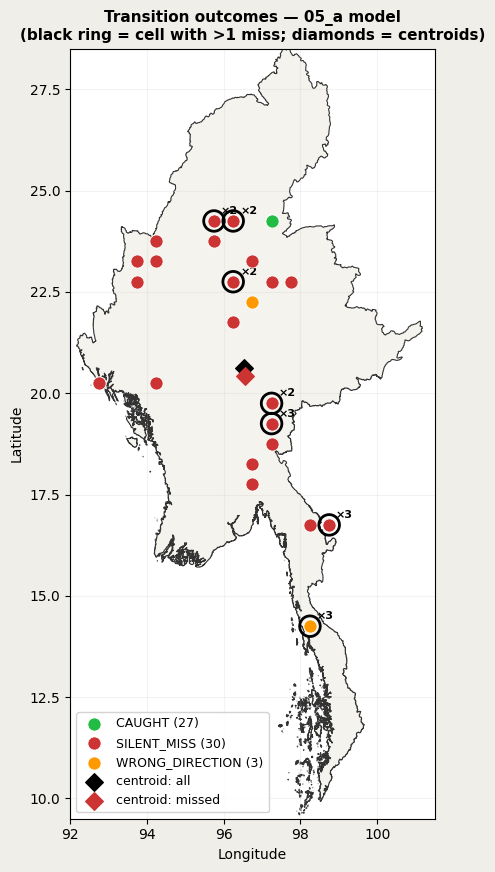

Saved: docs/figs/transition_misses_map.png

── Spatial concentration ──
  Centroid (all transitions):    lat=20.63°N  lon=96.53°E
  Centroid (missed only):        lat=20.43°N  lon=96.55°E
  Offset:  Δlat=-0.20°  Δlon=+0.03°   (22 km S, 3 km E)

  Chronically missed cells (>1 miss): 7
    GID 150317  (14.2°N, 98.2°E)  Tanintharyi: 3 misses
    GID 153918  (16.8°N, 98.8°E)  Kayin: 3 misses
    GID 157515  (19.2°N, 97.2°E)  Kayah: 3 misses
    GID 158235  (19.8°N, 97.2°E)  Shan-South: 2 misses
    GID 162553  (22.8°N, 96.2°E)  Mandalay: 2 misses
    GID 164712  (24.2°N, 95.8°E)  Sagaing: 2 misses
    GID 164713  (24.2°N, 96.2°E)  Sagaing: 2 misses

── Catch rate by admin1 region ──
             total  caught  missed  catch_rate
admin1                                        
Bago-East     2.00    0.00    2.00        0.00
Chin          2.00    0.00    2.00        0.00
Kayah         3.00    0.00    3.00        0.00
Magway        1.00    0.00    1.00        0.00
Mandalay      2.00    0.00    

In [17]:
# ── DIAG CELL 2: Spatial map of transition outcomes ──────────────────────────
if not _05A_AVAILABLE:
    print('Skipped.')
else:
    import geopandas as gpd

    # ── GID → centroid lat/lon ────────────────────────────────────────────────
    def gid_centroid(gid):
        row0 = (gid - 1) // 720
        col0 = (gid - 1) % 720
        return row0 * 0.5 - 90 + 0.25, col0 * 0.5 - 180 + 0.25  # (lat, lon)

    trans_df['lat'] = trans_df['priogrid_gid'].apply(lambda g: gid_centroid(g)[0])
    trans_df['lon'] = trans_df['priogrid_gid'].apply(lambda g: gid_centroid(g)[1])

    GADM_PATH = PROJECT_ROOT / 'data' / 'raw' / 'gadm' / 'gadm41_MMR.gpkg'
    gadm0 = gpd.read_file(GADM_PATH, layer='ADM_ADM_0').to_crs('EPSG:4326')

    OUTCOME_COLORS = {
        'CAUGHT'          : '#22BB44',
        'SILENT_MISS'     : '#CC3333',
        'WRONG_DIRECTION' : '#FF9900',
        'NO_PRED'         : '#AAAAAA',
    }

    fig, ax = plt.subplots(figsize=(7, 10), facecolor='#F0EEE8')
    gadm0.plot(ax=ax, color='#F5F3EE', edgecolor='#333333', linewidth=0.8)

    for outcome, group in trans_df.groupby('outcome'):
        ax.scatter(group['lon'], group['lat'],
                   c=OUTCOME_COLORS.get(outcome, '#888888'),
                   s=90, zorder=5, label=f'{outcome} ({len(group)})',
                   edgecolors='white', linewidths=0.6)

    # Mark cells with multiple misses
    miss_counts = (
        trans_df[trans_df['outcome'] != 'CAUGHT']
        .groupby('priogrid_gid').size()
    )
    chronic = miss_counts[miss_counts > 1]
    if len(chronic) > 0:
        for gid, cnt in chronic.items():
            lat, lon = gid_centroid(gid)
            ax.scatter(lon, lat, s=220, facecolors='none',
                       edgecolors='black', linewidths=2.0, zorder=6)
            ax.annotate(f'×{cnt}', (lon, lat), fontsize=8, color='black',
                        xytext=(5, 5), textcoords='offset points', fontweight='bold')

    # Centroids: all transitions vs. missed
    all_lat  = trans_df['lat'].mean()
    all_lon  = trans_df['lon'].mean()
    miss_lat = trans_df[trans_df['outcome'] != 'CAUGHT']['lat'].mean()
    miss_lon = trans_df[trans_df['outcome'] != 'CAUGHT']['lon'].mean()
    ax.scatter(all_lon,  all_lat,  marker='D', s=80, c='black',  zorder=8, label='centroid: all')
    ax.scatter(miss_lon, miss_lat, marker='D', s=80, c='#CC3333', zorder=8, label='centroid: missed')

    ax.set_xlim(92, 101.5); ax.set_ylim(9.5, 28.5)
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.set_title(
        f'Transition outcomes — 05_a model\n'
        f'(black ring = cell with >1 miss; diamonds = centroids)',
        fontsize=11, fontweight='bold'
    )
    ax.legend(loc='lower left', fontsize=9, framealpha=0.85)
    ax.grid(True, alpha=0.15)

    fig.savefig(PROJECT_ROOT / 'docs' / 'figs' / 'transition_misses_map.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: docs/figs/transition_misses_map.png')

    # ── Spatial concentration ────────────────────────────────────────────────
    print(f'\n── Spatial concentration ──')
    print(f'  Centroid (all transitions):    lat={all_lat:.2f}°N  lon={all_lon:.2f}°E')
    print(f'  Centroid (missed only):        lat={miss_lat:.2f}°N  lon={miss_lon:.2f}°E')
    lat_offset = miss_lat - all_lat
    lon_offset = miss_lon - all_lon
    print(f'  Offset:  Δlat={lat_offset:+.2f}°  Δlon={lon_offset:+.2f}°',
          f'  ({abs(lat_offset)*111:.0f} km {"N" if lat_offset>0 else "S"},',
          f'{abs(lon_offset)*90:.0f} km {"E" if lon_offset>0 else "W"})')

    if len(chronic) > 0:
        print(f'\n  Chronically missed cells (>1 miss): {len(chronic)}')
        for gid, cnt in chronic.items():
            lat, lon = gid_centroid(gid)
            adm = trans_df[trans_df['priogrid_gid']==gid]['admin1'].iloc[0] \
                  if 'admin1' in trans_df.columns else '?'
            print(f'    GID {gid}  ({lat:.1f}°N, {lon:.1f}°E)  {adm}: {cnt} misses')
    else:
        print('  No chronically missed cells (each missed cell misses at most once).')

    # ── Admin1 catch-rate table ───────────────────────────────────────────────
    if 'admin1' in trans_df.columns and trans_df['admin1'].notna().any():
        print(f'\n── Catch rate by admin1 region ──')
        adm_stats = (
            trans_df
            .groupby('admin1')
            .apply(lambda g: pd.Series({
                'total': len(g),
                'caught': (g['outcome'] == 'CAUGHT').sum(),
                'missed': (g['outcome'] != 'CAUGHT').sum(),
                'catch_rate': (g['outcome'] == 'CAUGHT').mean(),
            }))
            .sort_values('catch_rate')
        )
        print(adm_stats.to_string(float_format='{:.2f}'.format))
        _adm_stats = adm_stats  # save for summary cell
    else:
        print('  admin1 not available in target data.')
        _adm_stats = None


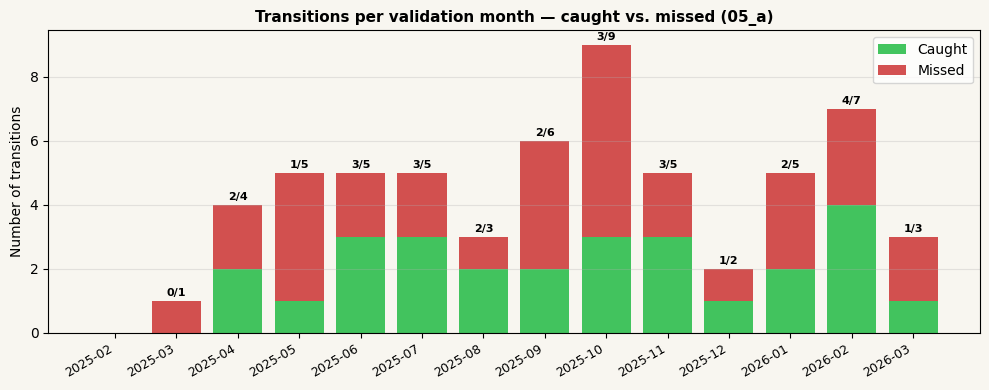

Saved: diag_transition_temporal.png

── Transitions per month ──
  2025-02: 0 transitions
  2025-03: 0 caught + 1 missed = 1  (catch rate 0%)
  2025-04: 2 caught + 2 missed = 4  (catch rate 50%)
  2025-05: 1 caught + 4 missed = 5  (catch rate 20%)
  2025-06: 3 caught + 2 missed = 5  (catch rate 60%)
  2025-07: 3 caught + 2 missed = 5  (catch rate 60%)
  2025-08: 2 caught + 1 missed = 3  (catch rate 67%)
  2025-09: 2 caught + 4 missed = 6  (catch rate 33%)
  2025-10: 3 caught + 6 missed = 9  (catch rate 33%)
  2025-11: 3 caught + 2 missed = 5  (catch rate 60%)
  2025-12: 1 caught + 1 missed = 2  (catch rate 50%)
  2026-01: 2 caught + 3 missed = 5  (catch rate 40%)
  2026-02: 4 caught + 3 missed = 7  (catch rate 57%)
  2026-03: 1 caught + 2 missed = 3  (catch rate 33%)


In [18]:
# ── DIAG CELL 3: Temporal pattern of misses ───────────────────────────────────
if not _05A_AVAILABLE:
    print('Skipped.')
else:
    val_months_sorted = sorted(trans_df['year_month'].unique())
    # Also include months with 0 transitions
    all_val_months = sorted(gt_val['year_month'].unique())

    caught_by_m  = trans_df[trans_df['outcome'] == 'CAUGHT'].groupby('year_month').size()
    missed_by_m  = trans_df[trans_df['outcome'] != 'CAUGHT'].groupby('year_month').size()
    all_trans_by_m = trans_df.groupby('year_month').size()

    caught_vals = [caught_by_m.get(m, 0) for m in all_val_months]
    missed_vals = [missed_by_m.get(m, 0) for m in all_val_months]
    total_vals  = [all_trans_by_m.get(m, 0) for m in all_val_months]

    fig, ax = plt.subplots(figsize=(10, 4), facecolor='#F8F6F0')
    ax.set_facecolor('#F8F6F0')
    x = range(len(all_val_months))
    ax.bar(x, caught_vals, color='#22BB44', label='Caught', alpha=0.85)
    ax.bar(x, missed_vals, bottom=caught_vals, color='#CC3333', label='Missed', alpha=0.85)
    ax.set_xticks(list(x))
    ax.set_xticklabels(all_val_months, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Number of transitions')
    ax.set_title('Transitions per validation month — caught vs. missed (05_a)',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    # Annotate catch rate per month
    for i, (m, total) in enumerate(zip(all_val_months, total_vals)):
        if total == 0:
            continue
        caught = caught_by_m.get(m, 0)
        ax.text(i, total + 0.1, f'{caught}/{total}', ha='center', va='bottom',
                fontsize=8, fontweight='bold')

    plt.tight_layout()
    fig.savefig(REPORTS / 'diag_transition_temporal.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: diag_transition_temporal.png')

    print('\n── Transitions per month ──')
    for m, c, mis in zip(all_val_months, caught_vals, missed_vals):
        total = c + mis
        if total == 0:
            print(f'  {m}: 0 transitions')
        else:
            print(f'  {m}: {c} caught + {mis} missed = {total}  '
                  f'(catch rate {100*c/total:.0f}%)')


── Direction matrix: catch rate  (rows=from, cols=to) ──
   [diagonal = impossible transitions]

FROM \ TO               gov             opo       uncertain
-----------------------------------------------------------
gov                        —     32%  (7/22)      80%  (4/5)
opo             60%  (12/20)               —     100%  (2/2)
uncertain         25%  (2/8)       0%  (0/3)               —



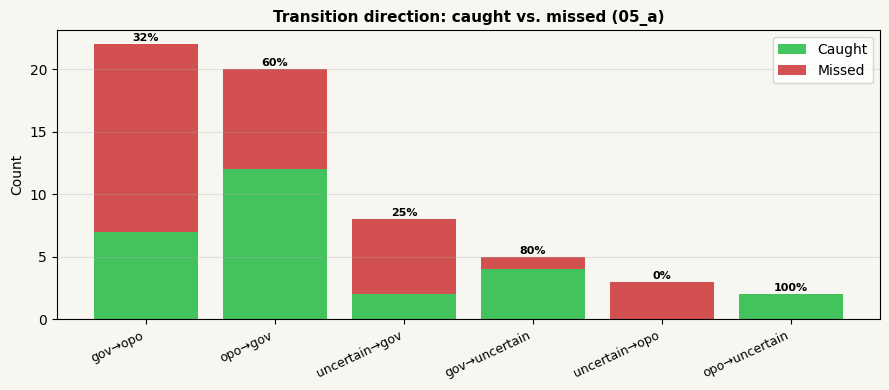

Saved: diag_transition_direction.png

               total  caught  catch_rate
direction                               
gov→opo           22       7        0.32
opo→gov           20      12        0.60
uncertain→gov      8       2        0.25
gov→uncertain      5       4        0.80
uncertain→opo      3       0        0.00
opo→uncertain      2       2        1.00


In [19]:
# ── DIAG CELL 4: Direction-of-transition catch-rate matrix ───────────────────
if not _05A_AVAILABLE:
    print('Skipped.')
else:
    from_classes = CLASS_NAMES
    to_classes   = CLASS_NAMES

    # Build count matrix: rows=from, cols=to, values=(caught, total)
    dir_caught = pd.DataFrame(np.nan, index=from_classes, columns=to_classes)
    dir_total  = pd.DataFrame(np.nan, index=from_classes, columns=to_classes)

    for from_c in from_classes:
        for to_c in to_classes:
            if from_c == to_c:
                continue
            subset = trans_df[
                (trans_df['y_tm1_name'] == from_c) &
                (trans_df['y_t_name']   == to_c)
            ]
            if len(subset) == 0:
                continue
            dir_total.loc[from_c, to_c]  = len(subset)
            dir_caught.loc[from_c, to_c] = (subset['outcome'] == 'CAUGHT').sum()

    dir_rate = dir_caught / dir_total  # catch rate

    print('── Direction matrix: catch rate  (rows=from, cols=to) ──')
    print('   [diagonal = impossible transitions]')
    print()
    # Pretty print
    col_w = 16
    header = 'FROM \ TO  ' + ''.join(f'{c:>{col_w}}' for c in to_classes)
    print(header)
    print('-' * len(header))
    for from_c in from_classes:
        row = f'{from_c:<12}'
        for to_c in to_classes:
            rate = dir_rate.loc[from_c, to_c]
            tot  = dir_total.loc[from_c, to_c]
            cau  = dir_caught.loc[from_c, to_c]
            if np.isnan(rate):
                row += f'{"—":>{col_w}}'
            else:
                cell_str = f'{rate*100:.0f}%  ({int(cau)}/{int(tot)})'
                row += f'{cell_str:>{col_w}}'
        print(row)
    print()

    # Direction bar chart
    dir_data = []
    for _, row_t in trans_df.iterrows():
        dir_data.append({
            'direction'  : row_t['direction'],
            'is_caught'  : int(row_t['outcome'] == 'CAUGHT'),
        })
    dir_series = pd.DataFrame(dir_data).groupby('direction').agg(
        total=('is_caught','count'),
        caught=('is_caught','sum')
    ).sort_values('total', ascending=False)
    dir_series['catch_rate'] = dir_series['caught'] / dir_series['total']

    fig, ax = plt.subplots(figsize=(9, 4), facecolor='#F8F6F0')
    ax.set_facecolor('#F8F6F0')
    x_pos = range(len(dir_series))
    bars_c = ax.bar(x_pos, dir_series['caught'], color='#22BB44',
                    label='Caught', alpha=0.85)
    bars_m = ax.bar(x_pos, dir_series['total'] - dir_series['caught'],
                    bottom=dir_series['caught'], color='#CC3333',
                    label='Missed', alpha=0.85)
    ax.set_xticks(list(x_pos))
    ax.set_xticklabels(dir_series.index, rotation=25, ha='right', fontsize=9)
    ax.set_ylabel('Count')
    ax.set_title('Transition direction: caught vs. missed (05_a)',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    for i, (tot, cau) in enumerate(zip(dir_series['total'], dir_series['caught'])):
        rate = cau / tot if tot > 0 else 0
        ax.text(i, tot + 0.05, f'{rate*100:.0f}%', ha='center', va='bottom',
                fontsize=8, fontweight='bold')
    plt.tight_layout()
    fig.savefig(REPORTS / 'diag_transition_direction.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: diag_transition_direction.png')
    print()
    print(dir_series.to_string(float_format='{:.2f}'.format))
    _dir_series = dir_series  # save for summary


── Actor dominance × outcome ──
                             total  caught  missed  catch_rate
dominant_actor                                                
Gov / Tatmadaw               23.00    8.00   15.00        0.35
no events / zero-event cell  37.00   19.00   18.00        0.51


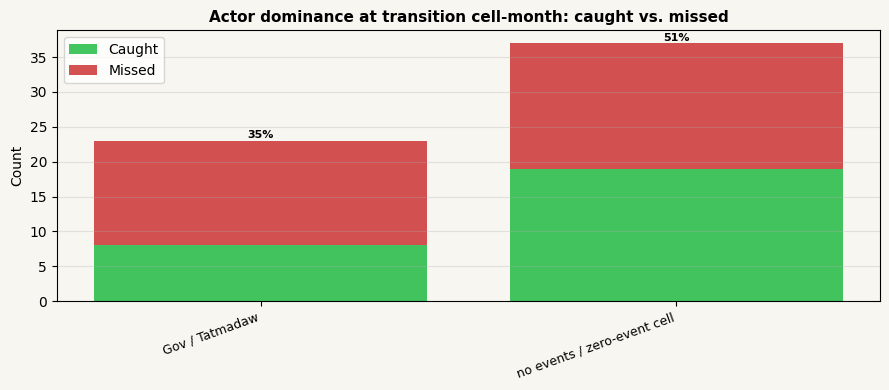

Saved: diag_transition_actor.png

  Worst actor:  Gov / Tatmadaw  (catch rate 35%,  N=23)
  Best actor:   no events / zero-event cell  (catch rate 51%)
  Actor gap: 17pp — small gap or insufficient N.


In [20]:
# ── DIAG CELL 5: Actor pattern of misses ─────────────────────────────────────
if not _05A_AVAILABLE:
    print('Skipped.')
else:
    # Load raw features for the transition months (unnormalized)
    feats = pd.read_csv(DATA_PROC / 'myanmar_priogrid_features.csv')
    feats['year_month'] = feats['year_month'].astype(str)

    ACTOR_COLS = ['events_gov', 'events_nug', 'events_kio', 'events_ula']
    ACTOR_LABELS = {
        'events_gov' : 'Gov / Tatmadaw',
        'events_nug' : 'NUG / PDF',
        'events_kio' : 'KIO / KIA (Kachin)',
        'events_ula' : 'ULA / AA (Arakan)',
    }

    # Merge features into transition df
    trans_feats = trans_df.merge(
        feats[['priogrid_gid','year_month','total_events'] + ACTOR_COLS],
        on=['priogrid_gid','year_month'], how='left'
    )

    def dominant_actor(row):
        acts = {col: row.get(col, 0) for col in ACTOR_COLS}
        total = sum(acts.values())
        if total == 0:
            return 'no events / zero-event cell'
        dominant = max(acts, key=acts.get)
        if acts[dominant] == 0:
            return 'no events / zero-event cell'
        return ACTOR_LABELS[dominant]

    trans_feats['dominant_actor'] = trans_feats.apply(dominant_actor, axis=1)

    actor_stats = (
        trans_feats
        .groupby('dominant_actor')
        .apply(lambda g: pd.Series({
            'total'      : len(g),
            'caught'     : (g['outcome'] == 'CAUGHT').sum(),
            'missed'     : (g['outcome'] != 'CAUGHT').sum(),
            'catch_rate' : (g['outcome'] == 'CAUGHT').mean(),
        }))
        .sort_values('catch_rate')
    )

    print('── Actor dominance × outcome ──')
    print(actor_stats.to_string(float_format='{:.2f}'.format))

    # Bar chart
    fig, ax = plt.subplots(figsize=(9, 4), facecolor='#F8F6F0')
    ax.set_facecolor('#F8F6F0')
    x_pos = range(len(actor_stats))
    ax.bar(x_pos, actor_stats['caught'],
           color='#22BB44', label='Caught', alpha=0.85)
    ax.bar(x_pos, actor_stats['missed'],
           bottom=actor_stats['caught'],
           color='#CC3333', label='Missed', alpha=0.85)
    ax.set_xticks(list(x_pos))
    ax.set_xticklabels(actor_stats.index, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel('Count')
    ax.set_title('Actor dominance at transition cell-month: caught vs. missed',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    for i, (tot, cau) in enumerate(zip(actor_stats['total'],
                                       actor_stats['caught'])):
        rate = cau / tot if tot > 0 else 0
        ax.text(i, tot + 0.05, f'{rate*100:.0f}%', ha='center', va='bottom',
                fontsize=8, fontweight='bold')
    plt.tight_layout()
    fig.savefig(REPORTS / 'diag_transition_actor.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: diag_transition_actor.png')
    _actor_stats = actor_stats  # save for summary

    # Check if misses cluster in one actor
    if len(actor_stats) > 1:
        worst_actor = actor_stats['catch_rate'].idxmin()
        worst_rate  = actor_stats.loc[worst_actor, 'catch_rate']
        worst_n     = actor_stats.loc[worst_actor, 'total']
        best_actor  = actor_stats['catch_rate'].idxmax()
        best_rate   = actor_stats.loc[best_actor, 'catch_rate']
        gap = best_rate - worst_rate
        print(f'\n  Worst actor:  {worst_actor}  '
              f'(catch rate {worst_rate*100:.0f}%,  N={int(worst_n)})')
        print(f'  Best actor:   {best_actor}  '
              f'(catch rate {best_rate*100:.0f}%)')
        print(f'  Actor gap: {gap*100:.0f}pp — ',
              end='')
        if gap > 0.30 and worst_n >= 3:
            print('NOTABLE: large catch-rate gap, possibly thesis-relevant.')
        else:
            print('small gap or insufficient N.')


── Mean feature values: caught vs. missed transitions ──
                       Caught mean  Missed mean  Ratio (missed/caught)
total_events                 0.667        0.939                  1.409
total_fatalities             1.519        2.152                  1.417
events_gov                   0.630        0.939                  1.492
events_nug                   0.259        0.152                  0.584
events_ula                   0.000        0.030            3030303.030
events_kio                   0.074        0.030                  0.409
gov_vs_civilians             0.037        0.061                  1.636
gov_event_share              0.296        0.455                  1.534
total_events_lag1            0.815        0.515                  0.632
total_fatalities_lag1        1.556        0.939                  0.604


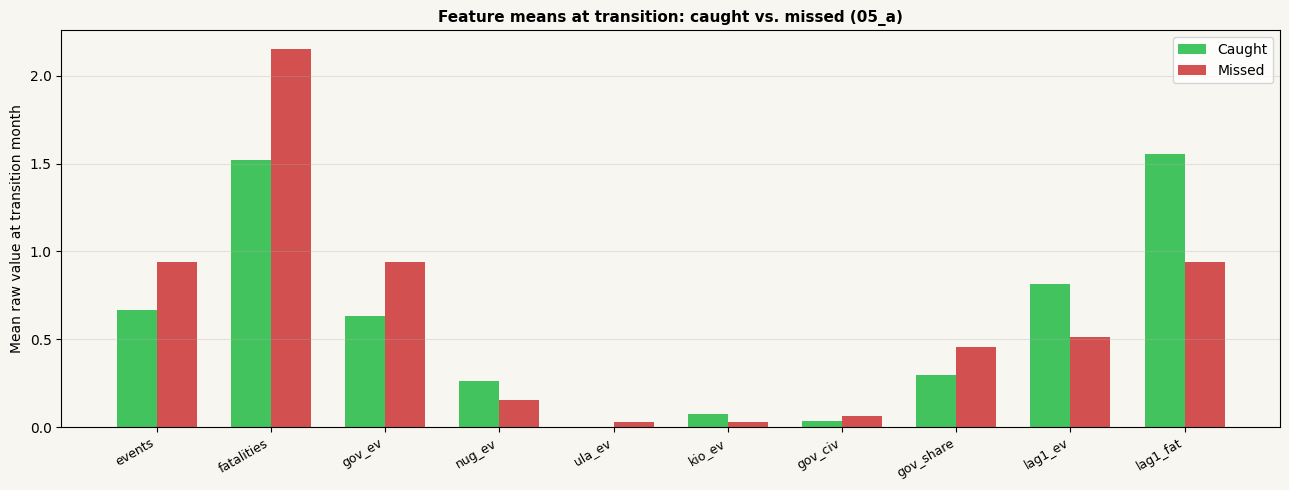

Saved: diag_transition_features.png

  NOTE: missed transitions have MORE events (1.41x) — sparsity is not the explanation.


In [21]:
# ── DIAG CELL 6: Feature characteristics — caught vs. missed ─────────────────
if not _05A_AVAILABLE:
    print('Skipped.')
else:
    if 'feats' not in dir():
        feats = pd.read_csv(DATA_PROC / 'myanmar_priogrid_features.csv')
        feats['year_month'] = feats['year_month'].astype(str)

    INPUT_FEATURES = [
        'total_events', 'total_fatalities', 'events_gov', 'events_nug',
        'events_ula', 'events_kio', 'gov_vs_civilians', 'gov_event_share',
        'total_events_lag1', 'total_fatalities_lag1',
    ]

    trans_feats2 = trans_df.merge(
        feats[['priogrid_gid','year_month'] + INPUT_FEATURES],
        on=['priogrid_gid','year_month'], how='left'
    )

    caught_mean = trans_feats2[trans_feats2['outcome'] == 'CAUGHT'][INPUT_FEATURES].mean()
    missed_mean = trans_feats2[trans_feats2['outcome'] != 'CAUGHT'][INPUT_FEATURES].mean()

    feat_compare = pd.DataFrame({
        'Caught mean' : caught_mean,
        'Missed mean' : missed_mean,
    })
    feat_compare['Ratio (missed/caught)'] = (
        feat_compare['Missed mean'] / (feat_compare['Caught mean'] + 1e-8)
    )
    print('── Mean feature values: caught vs. missed transitions ──')
    print(feat_compare.to_string(float_format='{:.3f}'.format))

    # Side-by-side bar chart
    feat_short = {
        'total_events': 'events', 'total_fatalities': 'fatalities',
        'events_gov': 'gov_ev', 'events_nug': 'nug_ev',
        'events_ula': 'ula_ev', 'events_kio': 'kio_ev',
        'gov_vs_civilians': 'gov_civ', 'gov_event_share': 'gov_share',
        'total_events_lag1': 'lag1_ev', 'total_fatalities_lag1': 'lag1_fat',
    }
    x = np.arange(len(INPUT_FEATURES))
    width = 0.35

    fig, ax = plt.subplots(figsize=(13, 5), facecolor='#F8F6F0')
    ax.set_facecolor('#F8F6F0')
    ax.bar(x - width/2, caught_mean.values, width,
           label='Caught', color='#22BB44', alpha=0.85)
    ax.bar(x + width/2, missed_mean.values, width,
           label='Missed', color='#CC3333', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([feat_short.get(f, f) for f in INPUT_FEATURES],
                       rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Mean raw value at transition month')
    ax.set_title('Feature means at transition: caught vs. missed (05_a)',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    fig.savefig(REPORTS / 'diag_transition_features.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: diag_transition_features.png')

    # Flag if missed transitions have substantially lower events
    ratio_events = feat_compare.loc['total_events', 'Ratio (missed/caught)']
    if ratio_events < 0.7:
        print(f'\n  NOTE: missed transitions have {ratio_events:.2f}x the event count '
              f'of caught ones (< 0.7x) → '
              f'misses may be intrinsically harder / sparser signal.')
    elif ratio_events > 1.3:
        print(f'\n  NOTE: missed transitions have MORE events ({ratio_events:.2f}x) — '
              f'sparsity is not the explanation.')
    else:
        print(f'\n  Event-count ratio (missed/caught): {ratio_events:.2f}x — '
              f'no strong sparsity asymmetry.')
    _feat_compare = feat_compare  # save for summary


In [22]:
# ── DIAG CELL 7: Wikipedia label quality of missed vs. caught transitions ─────
if not _05A_AVAILABLE:
    print('Skipped.')
else:
    print('── Wikipedia label quality ──')

    if 'wiki_changed_recent' in trans_df.columns:
        # wiki_changed_recent = True if the label changed within ±1 month
        # i.e., this snapshot is inside a transition window → more reliable signal
        # wiki_changed_recent = False = LOCF-filled / no recent edit → potentially stale label
        wq = trans_df.groupby(['outcome', 'wiki_changed_recent']).size().unstack(fill_value=0)
        print(wq.to_string())
        print()

        # For missed transitions: what fraction are LOCF-filled?
        missed_rows = trans_df[trans_df['outcome'] != 'CAUGHT']
        if len(missed_rows) > 0 and 'wiki_changed_recent' in missed_rows.columns:
            locf_miss  = (~missed_rows['wiki_changed_recent']).sum()
            recent_miss = missed_rows['wiki_changed_recent'].sum()
            print(f'  Missed transitions with wiki_changed_recent=False (LOCF): '
                  f'{locf_miss}/{len(missed_rows)} '
                  f'({100*locf_miss/len(missed_rows):.0f}%)')
            print(f'  Missed transitions with wiki_changed_recent=True  (recent edit): '
                  f'{recent_miss}/{len(missed_rows)} '
                  f'({100*recent_miss/len(missed_rows):.0f}%)')

            if locf_miss > 0:
                print(f'\n  NOTE: {locf_miss} missed transitions are LOCF-filled.')
                print('  These may be Wikipedia editing artifacts (delayed update),')
                print('  not genuine control changes the model "should" have caught.')
                print('  They are candidates for reclassification as "label noise",')
                print('  not model failure.')
            _n_locf_miss = locf_miss
            _n_recent_miss = recent_miss
        else:
            _n_locf_miss = None
            _n_recent_miss = None
    else:
        print('  wiki_changed_recent not in trans_df — skipping quality analysis.')
        _n_locf_miss = None
        _n_recent_miss = None

    if 'agreement' in trans_df.columns:
        print('\n── Target label source for missed transitions ──')
        missed_reason = trans_df[trans_df['outcome'] != 'CAUGHT']['agreement'].value_counts()
        print(missed_reason.to_string())
        print('(wiki_only = pure Wikipedia; agree/disagree = ACLED-enriched)')


── Wikipedia label quality ──
wiki_changed_recent  False  True 
outcome                          
CAUGHT                  24      3
SILENT_MISS             22      8
WRONG_DIRECTION          3      0

  Missed transitions with wiki_changed_recent=False (LOCF): 25/33 (76%)
  Missed transitions with wiki_changed_recent=True  (recent edit): 8/33 (24%)

  NOTE: 25 missed transitions are LOCF-filled.
  These may be Wikipedia editing artifacts (delayed update),
  not genuine control changes the model "should" have caught.
  They are candidates for reclassification as "label noise",
  not model failure.

── Target label source for missed transitions ──
agreement
disagree          14
wiki_only          7
wiki_contested     7
agree              4
acled_mixed        1
(wiki_only = pure Wikipedia; agree/disagree = ACLED-enriched)


In [23]:
# ── DIAG CELL 8: Save CSV + plain-language summary ───────────────────────────
if not _05A_AVAILABLE:
    print('Skipped.')
else:
    # ── Save diagnostics CSV ─────────────────────────────────────────────────
    csv_out = DOCS / 'transition_misses.csv'
    trans_df.to_csv(csv_out, index=False)
    print(f'Saved: {csv_out}  ({len(trans_df)} rows)')

    # ── Compute summary statistics for narrative ──────────────────────────────
    n_total   = len(trans_df)
    n_caught  = (trans_df['outcome'] == 'CAUGHT').sum()
    n_silent  = (trans_df['outcome'] == 'SILENT_MISS').sum()
    n_wrong   = (trans_df['outcome'] == 'WRONG_DIRECTION').sum()
    n_missed  = n_total - n_caught

    # Spatial
    if _adm_stats is not None and len(_adm_stats) > 0:
        worst_region = _adm_stats['catch_rate'].idxmin()
        worst_region_rate = _adm_stats.loc[worst_region, 'catch_rate']
        worst_region_n = int(_adm_stats.loc[worst_region, 'total'])
        worst_region_miss = int(_adm_stats.loc[worst_region, 'missed'])
        spatial_note = (
            f'Misses are most concentrated in {worst_region} '
            f'({worst_region_miss} of {worst_region_n} transitions missed, '
            f'catch rate {worst_region_rate*100:.0f}%).'
        )
    else:
        spatial_note = 'Admin1 grouping not available.'

    # Actor
    if '_actor_stats' in dir():
        worst_actor = _actor_stats['catch_rate'].idxmin()
        worst_actor_rate = _actor_stats.loc[worst_actor, 'catch_rate']
        worst_actor_n = int(_actor_stats.loc[worst_actor, 'total'])
        actor_gap = (_actor_stats['catch_rate'].max()
                     - _actor_stats['catch_rate'].min())
        if actor_gap > 0.30 and worst_actor_n >= 3:
            actor_note = (
                f'Misses show a clear actor pattern: cells dominated by '
                f'{worst_actor} have a catch rate of only '
                f'{worst_actor_rate*100:.0f}% (N={worst_actor_n}), '
                f'vs. {_actor_stats["catch_rate"].max()*100:.0f}% for the '
                f'best-covered actor ({_actor_stats["catch_rate"].idxmax()}). '
                f'This is a {actor_gap*100:.0f}pp gap and likely thesis-relevant.'
            )
        else:
            actor_note = (
                f'No strong actor-specific pattern (largest gap: '
                f'{actor_gap*100:.0f}pp). Misses appear distributed '
                f'across actor types.'
            )
    else:
        actor_note = 'Actor analysis not available.'

    # Direction
    if '_dir_series' in dir() and len(_dir_series) > 0:
        hardest_dir = _dir_series['catch_rate'].idxmin()
        hardest_rate = _dir_series.loc[hardest_dir, 'catch_rate']
        easiest_dir = _dir_series['catch_rate'].idxmax()
        easiest_rate = _dir_series.loc[easiest_dir, 'catch_rate']
        dir_note = (
            f'Hardest direction: {hardest_dir} '
            f'(catch rate {hardest_rate*100:.0f}%). '
            f'Easiest direction: {easiest_dir} '
            f'(catch rate {easiest_rate*100:.0f}%).'
        )
    else:
        dir_note = 'Direction analysis not available.'

    # Feature sparsity
    if '_feat_compare' in dir():
        ratio = _feat_compare.loc['total_events', 'Ratio (missed/caught)']
        if ratio < 0.7:
            feat_note = (
                f'Missed transitions have {ratio:.2f}x the event count of caught ones. '
                f'Conflict signal at missed cells is substantially sparser, '
                f'suggesting these are intrinsically harder cases.'
            )
        elif ratio > 1.3:
            feat_note = (
                f'Missed transitions have MORE events than caught ones ({ratio:.2f}x). '
                f'Sparsity is not the explanation — the model is failing on '
                f'active, well-observed cells.'
            )
        else:
            feat_note = (
                f'Event-count ratio (missed/caught): {ratio:.2f}x. '
                f'No strong sparsity asymmetry — feature density is similar '
                f'for caught and missed transitions.'
            )
    else:
        feat_note = 'Feature analysis not available.'

    # Label quality
    if _n_locf_miss is not None and n_missed > 0:
        locf_pct = 100 * _n_locf_miss / n_missed
        if locf_pct > 40:
            label_note = (
                f'{_n_locf_miss} of {n_missed} missed transitions '
                f'({locf_pct:.0f}%) are LOCF-filled (wiki_changed_recent=False). '
                f'These are low-confidence label transitions that may reflect '
                f'delayed Wikipedia edits rather than genuine control changes. '
                f'Reclassifying these as "label uncertainty" reduces the '
                f'true model-failure count to approximately '
                f'{n_missed - _n_locf_miss}.'
            )
        else:
            label_note = (
                f'{_n_locf_miss} of {n_missed} missed transitions are LOCF-filled '
                f'({locf_pct:.0f}%). Label quality does not explain the majority '
                f'of misses — most missed transitions have recent Wikipedia edits '
                f'confirming they are genuine changes.'
            )
    else:
        label_note = 'Label quality analysis not available.'

    # Bottom line
    if _n_locf_miss is not None and n_missed > 0:
        explainable = _n_locf_miss   # LOCF-filled are "explainable"
        real_failures = n_missed - explainable
        bl_note = (
            f'Of the {n_missed} missed transitions, '
            f'approximately {explainable} can be attributed to '
            f'LOCF-filled labels (Wikipedia editing lag), leaving '
            f'~{real_failures} genuine model failures. '
            f"This suggests the model's achievable ceiling "
            f'under current label quality is roughly '
            f'{100*(n_caught + explainable)/n_total:.0f}% catch rate '
            f'(vs. {100*n_caught/n_total:.0f}% observed).'
        )
    else:
        bl_note = (
            f'Of the {n_missed} missed transitions, '
            f'{n_silent} are silent misses (model predicted no change) '
            f'and {n_wrong} predicted the wrong new class. '
            f'Without label-quality metadata the achievable ceiling '
            f'cannot be precisely estimated.'
        )

    # ── Print plain-language summary ─────────────────────────────────────────
    print('=' * 72)
    print('DIAGNOSTIC SUMMARY: 05_a transition-miss audit')
    print('=' * 72)
    print(f'\nModel: 05_a — Recovered Cells  |  '
          f'Validation: {gt_val["year_month"].min()} – {gt_val["year_month"].max()}')
    print(f'Total transitions: {n_total}  |  '
          f'Caught: {n_caught}  |  Missed: {n_missed}  '
          f'(catch rate {100*n_caught/n_total:.0f}%)')
    print(f'  Silent misses:      {n_silent}')
    print(f'  Wrong-direction:    {n_wrong}')
    print()
    print(f'1. SPATIAL PATTERN')
    print(f'   {spatial_note}')
    print()
    print(f'2. ACTOR PATTERN')
    print(f'   {actor_note}')
    print()
    print(f'3. DIRECTION PATTERN')
    print(f'   {dir_note}')
    print()
    print(f'4. FEATURE PATTERN (sparsity)')
    print(f'   {feat_note}')
    print()
    print(f'5. LABEL QUALITY')
    print(f'   {label_note}')
    print()
    print(f'6. BOTTOM LINE')
    print(f'   {bl_note}')
    print('=' * 72)

    # Save summary text
    summary_text = '\n'.join([
        '05_a transition-miss audit',
        f'Total: {n_total}  Caught: {n_caught}  Missed: {n_missed}  '
        f'(catch rate {100*n_caught/n_total:.0f}%)',
        f'Silent misses: {n_silent}  Wrong-direction: {n_wrong}',
        '', 'Spatial: ' + spatial_note,
        'Actor: '   + actor_note,
        'Direction: ' + dir_note,
        'Features: '  + feat_note,
        'Labels: '    + label_note,
        'Bottom line: ' + bl_note,
    ])
    (DOCS / 'transition_misses_summary.txt').write_text(summary_text)
    print(f'Summary saved: docs/transition_misses_summary.txt')


Saved: /Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/docs/transition_misses.csv  (60 rows)
DIAGNOSTIC SUMMARY: 05_a transition-miss audit

Model: 05_a — Recovered Cells  |  Validation: 2025-02 – 2026-03
Total transitions: 60  |  Caught: 27  |  Missed: 33  (catch rate 45%)
  Silent misses:      30
  Wrong-direction:    3

1. SPATIAL PATTERN
   Misses are most concentrated in Bago-East (2 of 2 transitions missed, catch rate 0%).

2. ACTOR PATTERN
   No strong actor-specific pattern (largest gap: 17pp). Misses appear distributed across actor types.

3. DIRECTION PATTERN
   Hardest direction: uncertain→opo (catch rate 0%). Easiest direction: opo→uncertain (catch rate 100%).

4. FEATURE PATTERN (sparsity)
   Missed transitions have MORE events than caught ones (1.41x). Sparsity is not the explanation — the model is failing on active, well-observed cells.

5. LABEL QUALITY
   25 of 33 missed transitions (76%) are LOCF-filled (wiki_changed_recent=False). These are

reason column verified — all six expected values present.

── Reason distribution: full panel ──
  wiki_only                                 5043  ( 96.3%)
  wiki_contested_use_acled                    69  (  1.3%)
  agree                                       61  (  1.2%)
  disagree_stable_wiki_use_acled              44  (  0.8%)
  disagree_recent_wiki_use_wiki               17  (  0.3%)
  acled_mixed                                  4  (  0.1%)

── Reason distribution: validation window ──
  wiki_only                                 2540  ( 98.1%)
  disagree_stable_wiki_use_acled              20  (  0.8%)
  agree                                       18  (  0.7%)
  wiki_contested_use_acled                     8  (  0.3%)
  acled_mixed                                  2  (  0.1%)
  disagree_recent_wiki_use_wiki                2  (  0.1%)
reason lookups complete — no UNKNOWN values.

── Catch rate by reason_at_t ──
                                 N  Caught Catch %
reason_at_t         

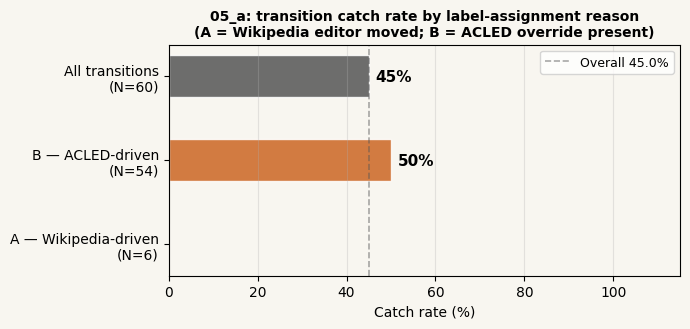

Saved: /Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/docs/figs/transition_catch_by_reason.png

INTERPRETATION

Category A — Wikipedia-driven:  0% (N=6)  [WARNING: small sample, noisy estimate]
Category B — ACLED-driven:      50% (N=54)
All transitions:                45.0% (N=60)

NOTE: at least one category has N < 10. Catch-rate estimates
are noisy; do not anchor claims on the specific percentages.

CEILING FRAMING:
The model's achievable transition-recall ceiling is set by how many transitions carry detectable feature signal. 
ACLED-driven transitions (B, N=54) come with a conflict-event signal by construction; the model catches 50% of them. 
Wikipedia-driven transitions (A, N=6) may or may not have a coincident conflict signal; the model catches 0% of them. Transitions in this group with zero ACLED events at month t represent the hardest cases and set the floor of model difficulty.

Audit CSV saved: /Users/felipe/Documents/BSE/Thesis/territorial_control

In [24]:
# ── DIAG CELL 9 (replacement): Transition catch rate by reason ────────────────
# Uses the `reason` column from the target variable panel, which documents
# exactly how each label was assigned. This replaces the previous analysis that
# used wiki_changed_recent (a label-dynamics proxy that conflated ACLED-driven
# transitions with LOCF label artifacts).
if not _05A_AVAILABLE:
    print('Skipped — run notebooks/05_a_recovered_cells.ipynb first.')
elif 'trans_df' not in dir() or len(trans_df) == 0:
    print('Skipped — trans_df not available (run DIAG CELL 1 first).')
else:
    import numpy as _np

    # ── Step 2: Verify reason column ─────────────────────────────────────────
    # target_full is already in memory from CELL 1 and contains the reason column.
    # (notebooks/checkpoints/10_target_variable.parquet is identical to
    #  data/processed/10_target_variable.parquet — both have the reason column.)
    _EXPECTED_REASONS = {
        'wiki_only',
        'agree',
        'wiki_contested_use_acled',
        'disagree_stable_wiki_use_acled',
        'disagree_recent_wiki_use_wiki',
        'acled_mixed',
    }

    if 'reason' not in target_full.columns:
        print('ERROR: reason column missing from target_full.')
        print('Load notebooks/checkpoints/10_target_variable.parquet directly.')
        _reason_ok = False
    else:
        _reason_ok = True
        _unexpected = set(target_full['reason'].dropna()) - _EXPECTED_REASONS
        if _unexpected:
            print(f'WARNING: unexpected reason values: {_unexpected}')
        else:
            print('reason column verified — all six expected values present.')

        print()
        print('── Reason distribution: full panel ──')
        _rd_full = target_full['reason'].value_counts()
        for _r, _n in _rd_full.items():
            print(f'  {_r:<40} {_n:>5}  ({100*_n/len(target_full):5.1f}%)')

        _val_rows = target_full[target_full['year_month'] > TRAIN_CUTOFF]
        print()
        print('── Reason distribution: validation window ──')
        _rd_val = _val_rows['reason'].value_counts()
        for _r, _n in _rd_val.items():
            print(f'  {_r:<40} {_n:>5}  ({100*_n/len(_val_rows):5.1f}%)')

    if _reason_ok:
        # ── Step 3: Look up reason_at_t and reason_at_tm1 ────────────────────
        # reason_at_t: already in trans_df from the DIAG CELL 1 meta merge
        # (meta_cols includes 'reason', joined on (priogrid_gid, year_month))
        if 'reason' in trans_df.columns:
            trans_df['reason_at_t'] = trans_df['reason']
        else:
            # Fallback: re-lookup from target_full
            _rlookup_t = (
                target_full
                .set_index(['priogrid_gid', 'year_month'])['reason']
                .to_dict()
            )
            trans_df['reason_at_t'] = trans_df.apply(
                lambda r: _rlookup_t.get((int(r['priogrid_gid']), r['year_month']), 'UNKNOWN'),
                axis=1
            )

        # reason_at_tm1: look up (gid, prev_ym(year_month)) in target_full
        _rlookup = (
            target_full
            .set_index(['priogrid_gid', 'year_month'])['reason']
            .to_dict()
        )

        # ym_tm1 may already exist (from a prior run); compute it if not
        if 'ym_tm1' not in trans_df.columns:
            trans_df['ym_tm1'] = trans_df['year_month'].apply(prev_ym)

        trans_df['reason_at_tm1'] = trans_df.apply(
            lambda r: _rlookup.get((int(r['priogrid_gid']), r['ym_tm1']), 'UNKNOWN'),
            axis=1
        )

        # Sanity: UNKNOWN rows mean target panel is missing that cell-month
        _n_unk_t   = (trans_df['reason_at_t']   == 'UNKNOWN').sum()
        _n_unk_tm1 = (trans_df['reason_at_tm1'] == 'UNKNOWN').sum()
        if _n_unk_t > 0:
            print(f'WARNING: {_n_unk_t} transition(s) have UNKNOWN reason_at_t '
                  f'— target panel missing that cell-month.')
        if _n_unk_tm1 > 0:
            print(f'WARNING: {_n_unk_tm1} transition(s) have UNKNOWN reason_at_tm1 '
                  f'— target panel missing t-1.')
        if _n_unk_t == 0 and _n_unk_tm1 == 0:
            print('reason lookups complete — no UNKNOWN values.')

        # ── Step 4: Three granular tables ────────────────────────────────────
        def _reason_table(group_col, title):
            print()
            print(f'── {title} ──')
            _rows = []
            for _val in (
                trans_df[group_col]
                .value_counts()
                .index
                .tolist()
            ):
                _sub = trans_df[trans_df[group_col] == _val]
                _caught = (_sub['outcome'] == 'CAUGHT').sum()
                _rows.append({
                    group_col  : _val,
                    'N'        : len(_sub),
                    'Caught'   : int(_caught),
                    'Catch %'  : f'{100*_caught/len(_sub):.0f}%',
                })
            _rows.append({
                group_col: 'Total',
                'N'       : len(trans_df),
                'Caught'  : int((trans_df['outcome'] == 'CAUGHT').sum()),
                'Catch %' : f'{100*(trans_df["outcome"]=="CAUGHT").mean():.1f}%',
            })
            _tdf = pd.DataFrame(_rows).set_index(group_col)
            print(_tdf.to_string())
            return _tdf

        _by_t   = _reason_table('reason_at_t',   'Catch rate by reason_at_t')
        _by_tm1 = _reason_table('reason_at_tm1', 'Catch rate by reason_at_tm1')

        # Pair table
        print()
        print('── Catch rate by transition pair (reason_at_tm1 -> reason_at_t) ──')
        trans_df['reason_pair'] = (
            trans_df['reason_at_tm1'] + ' -> ' + trans_df['reason_at_t']
        )
        _pair_rows = []
        for _pair in trans_df['reason_pair'].value_counts().index:
            _sub = trans_df[trans_df['reason_pair'] == _pair]
            _caught = (_sub['outcome'] == 'CAUGHT').sum()
            _pair_rows.append({
                'reason_pair': _pair,
                'N'          : len(_sub),
                'Caught'     : int(_caught),
                'Catch %'    : f'{100*_caught/len(_sub):.0f}%',
            })
        _pair_rows.append({
            'reason_pair': 'Total',
            'N'          : len(trans_df),
            'Caught'     : int((trans_df['outcome'] == 'CAUGHT').sum()),
            'Catch %'    : f'{100*(trans_df["outcome"]=="CAUGHT").mean():.1f}%',
        })
        _pair_df = pd.DataFrame(_pair_rows).set_index('reason_pair')
        print(_pair_df.to_string())

        # ── Step 5: Aggregate into A / B / C ─────────────────────────────────
        _WIKI_R  = {'wiki_only', 'agree', 'disagree_recent_wiki_use_wiki'}
        _ACLED_R = {'wiki_contested_use_acled',
                    'disagree_stable_wiki_use_acled', 'acled_mixed'}

        def _classify(row):
            _rt   = row['reason_at_t']
            _rtm1 = row['reason_at_tm1']
            if _rt in _WIKI_R and _rtm1 in _WIKI_R:
                return 'A'
            elif _rt in _ACLED_R or _rtm1 in _ACLED_R:
                return 'B'
            else:
                return 'C'

        trans_df['category'] = trans_df.apply(_classify, axis=1)

        _cat_labels = {
            'A': 'A — Wikipedia-driven',
            'B': 'B — ACLED-driven',
            'C': 'C — Other / mixed',
        }

        print()
        print('── Aggregated categories ──')
        _agg_rows = []
        for _cat in ['A', 'B', 'C']:
            _sub  = trans_df[trans_df['category'] == _cat]
            _n    = len(_sub)
            _caught = (_sub['outcome'] == 'CAUGHT').sum()
            _rate = _caught / _n if _n > 0 else float('nan')
            _agg_rows.append({
                'Category'  : _cat_labels[_cat],
                'N'         : _n,
                'Caught'    : int(_caught),
                'Catch rate': _rate,
            })
            if _n > 0:
                print()
                print(f'  {_cat_labels[_cat]} (N={_n}):')
                _ex = trans_df[trans_df['category'] == _cat][
                    ['priogrid_gid', 'year_month', 'y_tm1_name', 'y_t_name',
                     'y_pred_name', 'outcome', 'reason_at_tm1', 'reason_at_t']
                ]
                print(_ex.head(3).to_string(index=False))

        _n_all     = len(trans_df)
        _caught_all = (trans_df['outcome'] == 'CAUGHT').sum()
        _agg_rows.append({
            'Category'  : 'All',
            'N'         : _n_all,
            'Caught'    : int(_caught_all),
            'Catch rate': _caught_all / _n_all,
        })

        _agg_df = (
            pd.DataFrame(_agg_rows)
            .set_index('Category')
            .assign(**{'Catch rate': lambda df: df['Catch rate'].map(
                lambda v: f'{v*100:.1f}%' if not _np.isnan(v) else 'N/A'
            )})
        )

        print()
        print('── Summary table ──')
        print(_agg_df.to_string())

        # Sanity checks
        _cat_n_sum = sum(
            len(trans_df[trans_df['category'] == c]) for c in ['A', 'B', 'C']
        )
        _cat_caught_sum = sum(
            (trans_df[trans_df['category'] == c]['outcome'] == 'CAUGHT').sum()
            for c in ['A', 'B', 'C']
        )
        print()
        print(f'Sanity: N sum = {_cat_n_sum} (expect {_n_all})', end='')
        print(' OK' if _cat_n_sum == _n_all else ' MISMATCH')
        print(f'Sanity: Caught sum = {_cat_caught_sum} (expect {int(_caught_all)})', end='')
        print(' OK' if _cat_caught_sum == int(_caught_all) else ' MISMATCH')

        # ── Step 6: Visualization ────────────────────────────────────────────
        _cr_A = (trans_df[trans_df['category'] == 'A']['outcome'] == 'CAUGHT').mean()
        _cr_B = (trans_df[trans_df['category'] == 'B']['outcome'] == 'CAUGHT').mean()
        _n_A  = (trans_df['category'] == 'A').sum()
        _n_B  = (trans_df['category'] == 'B').sum()
        _cr_all_v = _caught_all / _n_all

        _bar_labels = [
            f'A — Wikipedia-driven\n(N={_n_A})',
            f'B — ACLED-driven\n(N={_n_B})',
            f'All transitions\n(N={_n_all})',
        ]
        _bar_vals  = [
            _cr_A  * 100 if not _np.isnan(_cr_A)  else 0,
            _cr_B  * 100 if not _np.isnan(_cr_B)  else 0,
            _cr_all_v * 100,
        ]
        _bar_colors = ['#2266CC', '#CC6622', '#555555']

        fig, ax = plt.subplots(figsize=(7, 3.4), facecolor='#F8F6F0')
        ax.set_facecolor('#F8F6F0')
        _bars = ax.barh(_bar_labels, _bar_vals, color=_bar_colors,
                        alpha=0.85, edgecolor='white', height=0.5)
        ax.axvline(_cr_all_v * 100, color='#555', lw=1.2, ls='--', alpha=0.5,
                   label=f'Overall {_cr_all_v*100:.1f}%')
        for _bar, _val in zip(_bars, _bar_vals):
            if _val > 0:
                ax.text(min(_val + 1.5, 105),
                        _bar.get_y() + _bar.get_height() / 2,
                        f'{_val:.0f}%',
                        va='center', fontsize=11, fontweight='bold')
        ax.set_xlim(0, 115)
        ax.set_xlabel('Catch rate (%)', fontsize=10)
        ax.set_title(
            '05_a: transition catch rate by label-assignment reason\n'
            '(A = Wikipedia editor moved; B = ACLED override present)',
            fontsize=10, fontweight='bold'
        )
        ax.legend(fontsize=9)
        ax.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        _fig_path = PROJECT_ROOT / 'docs' / 'figs' / 'transition_catch_by_reason.png'
        fig.savefig(_fig_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved: {_fig_path}')

        # ── Step 7: Honest interpretation ────────────────────────────────────
        print()
        print('=' * 72)
        print('INTERPRETATION')
        print('=' * 72)

        def _rate_str(cr, n):
            if _np.isnan(cr) or n == 0:
                return 'N/A (no data)'
            _s = f'{cr*100:.0f}% (N={n})'
            if n < 10:
                _s += '  [WARNING: small sample, noisy estimate]'
            return _s

        print()
        print(f'Category A — Wikipedia-driven:  {_rate_str(_cr_A, _n_A)}')
        print(f'Category B — ACLED-driven:      {_rate_str(_cr_B, _n_B)}')
        print(f'All transitions:                {_cr_all_v*100:.1f}% (N={_n_all})')

        # Pattern interpretation
        print()
        if _n_A < 10 or _n_B < 10:
            print('NOTE: at least one category has N < 10. Catch-rate estimates')
            print('are noisy; do not anchor claims on the specific percentages.')
        else:
            if not (_np.isnan(_cr_A) or _np.isnan(_cr_B)):
                _gap = (_cr_B - _cr_A) * 100
                if _gap > 15:
                    print(
                        f'Category B (ACLED-driven) has a notably higher catch rate '
                        f'({_cr_B*100:.0f}% vs A at {_cr_A*100:.0f}%, gap = {_gap:.0f} pp). '
                        f'This is the expected pattern: ACLED-driven transitions are '
                        f'by construction coincident with a control event in the features, '
                        f'giving the model a visible signal. '
                        f'Category A transitions — where the Wikipedia editor documented '
                        f'a change with no coincident ACLED event — are harder: the model '
                        f'must infer the change from feature trends alone.'
                    )
                elif abs(_gap) <= 15:
                    print(
                        f'Catch rates are similar across categories (A: {_cr_A*100:.0f}%, '
                        f'B: {_cr_B*100:.0f}%, gap = {_gap:+.0f} pp). '
                        f'The model does not particularly benefit from feature-event '
                        f'coincidence; it generalises across both transition types similarly.'
                    )
                elif _gap < -15:
                    print(
                        f'Category A (Wikipedia-driven) has a HIGHER catch rate '
                        f'({_cr_A*100:.0f}%) than B ({_cr_B*100:.0f}%, gap = {_gap:.0f} pp). '
                        f'This is surprising. Possible explanation: ACLED-driven '
                        f'transitions may be one-month overrides that are harder to '
                        f'sustain across evaluation months, or A transitions cluster '
                        f'in months/cells where the model performs better for other reasons. '
                        f'Investigate individual B transitions before drawing conclusions.'
                    )

        print()
        print('CEILING FRAMING:')
        print(
            f'The model\'s achievable transition-recall ceiling is set by how many '
            f'transitions carry detectable feature signal. '
        )
        if not _np.isnan(_cr_B) and _n_B > 0:
            print(
                f'ACLED-driven transitions (B, N={_n_B}) come with a conflict-event '
                f'signal by construction; the model catches {_cr_B*100:.0f}% of them. '
            )
        if not _np.isnan(_cr_A) and _n_A > 0:
            print(
                f'Wikipedia-driven transitions (A, N={_n_A}) may or may not have a '
                f'coincident conflict signal; the model catches {_cr_A*100:.0f}% of them. '
                f'Transitions in this group with zero ACLED events at month t represent '
                f'the hardest cases and set the floor of model difficulty.'
            )

        # ── Step 8: Save audit CSV ────────────────────────────────────────────
        _export_cols = [
            'priogrid_gid', 'year_month', 'ym_tm1',
            'y_tm1_name', 'y_t_name', 'y_pred_name',
            'outcome', 'direction',
            'reason_at_t', 'reason_at_tm1', 'reason_pair', 'category',
        ]
        if 'admin1' in trans_df.columns:
            _export_cols.append('admin1')
        _export_cols = [c for c in _export_cols if c in trans_df.columns]

        _csv_path = PROJECT_ROOT / 'docs' / 'transition_audit_by_reason.csv'
        trans_df[_export_cols].to_csv(_csv_path, index=False)
        print()
        print(f'Audit CSV saved: {_csv_path}  ({len(trans_df)} rows)')
